### 工作進度  
* 請參考與ChatGPT[對話](https://chatgpt.com/share/69fc9560-c178-83e8-93f1-a44fc6ea4896)內容。  
* 現階段架構與後續開發規格：  

# 股票技術分析 AI Agent — 現階段架構與後續開發規格

更新時間：2026-05

---

# 一、目前系統架構

目前系統已拆分為三個主要模組：

```text
MainTAAgent
 ├── VisualTAAnalyzer
 ├── PatternRecognizer
 └── ResponseComposer
```

設計原則：

- 趨勢分析與型態分析分離
- PatternRecognizer 專注於價格結構
- VisualTAAnalyzer 專注於技術分析與市場節奏
- ResponseComposer 僅負責語意整合與最終輸出

---

# 二、各模組職責

## 1. VisualTAAnalyzer

負責：

- K棒
- K線圖趨勢
- 成交量
- 移動平均線
- MACD
- KD

特性：

- 使用完整技術分析圖
- 可使用：
  - KD
  - MACD
  - 均線
  - 成交量
- 不負責型態識別
- 不負責雙重底、頭肩底等結構判斷

---

## 2. PatternRecognizer

負責：

- 型態識別
- 型態 lifecycle
- 頸線
- entry
- stop_loss
- target_price
- 型態合理性檢查

特性：

- 僅使用價格結構
- 不使用 KD / MACD
- 不參與一般技術分析
- 已獨立為專用 chart pipeline

目前已完成：

- 雙重底識別
- target 計算
- 前高合理性檢查
- lifecycle
- quant disagreement
- pattern_range

---

## 3. ResponseComposer

負責：

- 最終自然語言輸出
- JSON 格式輸出
- stock_etf / index 語境控制
- 日期格式
- KD/MACD 用語統一
- 型態輸出整理

特性：

- 不參與型態判斷
- 不參與技術分析推理
- 僅負責輸出整理

目前使用模型：

```python
ResponseComposer → GPT-5.2
```

目的：

- 降低成本
- 保持穩定格式輸出

目前觀察：

- 可正常運作
- 成本下降約四分之一
- 尚可接受

---

# 三、目前模型配置

```python
PatternRecognizer   → GPT-5.5
VisualTAAnalyzer   → GPT-5.5
ResponseComposer   → GPT-5.2
```

原因：

- 型態識別與視覺分析仍高度依賴 GPT-5.5 多模態能力
- ResponseComposer 已高度規格化，可降級為 GPT-5.2

---

# 四、PatternRecognizer 專用資料流（重要）

目前已完成：

```text
PatternRecognizer
 ← get_pattern_chart()
 ← get_pattern_chart_data()
```

與：

```text
VisualTAAnalyzer
 ← get_chart()
 ← get_chart_data()
```

完全分離。

---

# 五、Pattern 專用圖表規格

## get_pattern_chart()

用途：

型態辨識專用主圖。

目前規格：

- 僅保留價格主圖
- 保留成交量
- 移除 KD 子圖
- 移除 MACD 子圖
- 不輸出型態標記
- 可保留均線（目前保留 SMA20 / SMA60）

目前觀察：

- GPT attention 更集中於價格結構
- reasoning 更穩
- token 有下降
- 型態穩定性提升

目前不建議：

- 增加 RSI
- 增加 Bollinger
- 增加更多均線
- 增加型態標記

原因：

- 容易增加視覺噪音

---

# 六、Pattern 專用資料規格

## get_pattern_chart_data()

目前規格：

僅保留：

```python
{
    "date",
    "open",
    "high",
    "low",
    "close",
    "volume"
}
```

不包含：

- KD
- MACD
- OSC
- 均線
- 其他技術指標

目的：

- 降低 token
- 降低推理污染
- 聚焦價格結構

---

# 七、目前已確認的重要原則

## 原則 1

新型態完成，舊型態失去主導功能。

例如：

```text
雙重底成立
→ 後續被破壞
→ 再度進入更大型盤整
```

則原雙重底不再是主要型態。

目前系統尚未完整實作此 dominance 機制。

---

## 原則 2

同一張圖可能同時存在多種型態。

例如：

- 小型雙重底
- 大型三重底
- 更大盤整底部

可能同時存在。

目前 GPT-5.5 傾向：

- 選擇最近
- 最乾淨
- 最容易量化
- 最容易計算目標價

的小型態。

因此目前仍容易：

- 過度聚焦局部型態
- 忽略更大結構

---

# 八、目前已知 GPT-5 多模態限制

目前觀察：

GPT-5.5：

- 能看見局部型態
- 能計算頸線與 target
- 能處理 breakout
- 能做 lifecycle

但仍有：

- attention scope 不穩
- 傾向局部最清晰型態
- 不擅長 hierarchy
- 不擅長 dominance
- 不擅長大型複合底

目前問題層級已從：

```text
看不到型態
```

提升為：

```text
看得到局部型態
但無法正確管理型態層級
```

這代表系統已有進步。

---

# 九、目前已完成的重要改善

## 1. 移除 KD / MACD 對 PatternRecognizer 的污染

改善效果：

- reasoning 更短
- 結構更聚焦
- 型態更穩
- 誤判下降

---

## 2. pattern_range 可見化

目前 ResponseComposer 已要求：

- 已成形型態
- 未成形但存在候選型態

皆需輸出：

```text
型態區間約為 M月D日至M月D日
```

目的：

- 讓使用者知道 GPT 正在看哪一段
- 方便 benchmark
- 方便觀察型態 hierarchy 問題

---

## 3. quant disagreement

目前 PatternRecognizer 已可：

- 不直接照抄 quant_pattern_hint
- 能依價格結構自行判斷

這是重要改善。

---

# 十、目前不建議進行的大改動

目前先不要：

- 強制優先三重底
- 大改 hierarchy
- 大改 dominance
- 多型態排序系統
- 大型複合型態系統

原因：

目前穩定性剛建立。

過早修改容易造成：

```text
有型態 ↔ 無型態
```

之間重新漂移。

---

# 十一、未來可能的大型改版方向（暫不實作）

未來若要提升型態 hierarchy 能力，可能需要：

## Pattern Ranking / Dominance System

例如：

```text
候選型態 A
候選型態 B
候選型態 C
```

再依：

- recency
- breakout validity
- current relevance
- structural scale
- failure status
- lifecycle

進行排序。

此方向屬於：

```text
PatternRecognizer 第二代架構
```

不是小修改。

目前暫不進行。

---

# 十二、目前開發策略（重要）

目前優先目標：

```text
先穩定單一型態識別
```

而不是：

```text
一次解決所有型態 hierarchy 問題
```

目前最重要的是：

- 穩定性
- 可觀察性
- benchmark
- 可維護性

避免：

- 大規模 Prompt 疊加
- 過度複雜規則
- 有型態 / 無型態漂移

---

# 十三、後續 benchmark 建議

建議持續累積：

```text
人類判讀
vs
量化規則
vs
GPT-5.5
```

案例。

尤其：

- 雙重底
- 三重底
- 複合底
- 局部型態 vs 大型態

觀察：

- GPT attention 範圍
- hierarchy

In [1]:
import os
import pandas as pd
import numpy as np
import datetime
import sqlite3
import io
import base64
import matplotlib.pyplot as plt
import matplotlib
import mplfinance as mpf
import markdown

import json
import re

from scipy.signal import argrelextrema
from collections import defaultdict

from talib.abstract import *
from dotenv import load_dotenv, find_dotenv
from PIL import Image
from IPython.core.display import HTML

from typing import Any, Dict, List, Optional, Tuple
from openai import OpenAI

#### 量化技術分析工具  

In [2]:
##### 【公用函式】 來源 ： https://www.cnblogs.com/Rosaany/p/15561918.html #####
def get_monday_to_sunday(today, weekly=0):
    last = weekly * 7
    today = datetime.datetime.strptime(str(today), "%Y-%m-%d")
    monday = datetime.datetime.strftime(today - datetime.timedelta(today.weekday() - last), "%Y-%m-%d")
    monday_ = datetime.datetime.strptime(monday, "%Y-%m-%d")
    sunday = datetime.datetime.strftime(monday_ + datetime.timedelta(monday_.weekday() + 6), "%Y-%m-%d")
    return monday, sunday

###### 【內部函式】 當日Ｋ價格資料為零時之修正函式 ######
def correcting_zero_price_issue( daily_price_df, debug = False) :
    # 開啟寫時複製(Copy-on-Write)
    copy_on_write = pd.options.mode.copy_on_write
    pd.options.mode.copy_on_write = True
    
    # 找出開盤價、最高價、收盤價與最低價皆為0的價格資料
    zero_prices_df =  daily_price_df[(daily_price_df['Open'] == 0.0) & (daily_price_df['High'] == 0.0) & (daily_price_df['Low'] == 0.0) & (daily_price_df['Close'] == 0.0)]
    if zero_prices_df.empty is False :
        zero_prices_idx = zero_prices_df.index
        df_first_idx    = daily_price_df.iloc[0].name
        for idx in zero_prices_idx :
            if (idx - 1) >= df_first_idx :
                # 當開盤價、最高價、收盤價與最低價皆為0時，會用前一個交易日的收盤價來做修正
                prev_close_price = daily_price_df.loc[idx-1]['Close']
                prev_stock_id    = daily_price_df.loc[idx-1]['StockID']
                curr_stock_id    = daily_price_df.loc[idx]['StockID']
                if debug is True :
                    print('ＤＥＢＵＧ ： 〈代碼：{}，日期：{}〉  修改前：開 ＝ {} 高 ＝ {} 低 ＝ {} 收 ＝ {}'.format(curr_stock_id,daily_price_df.loc[idx]['Date'],daily_price_df.loc[idx,'Open'],daily_price_df.loc[idx,'High'],daily_price_df.loc[idx,'Low'],daily_price_df.loc[idx,'Close']), end='')
                daily_price_df.loc[idx,'Open']  = prev_close_price
                daily_price_df.loc[idx,'High']  = prev_close_price
                daily_price_df.loc[idx,'Low']   = prev_close_price
                daily_price_df.loc[idx,'Close'] = prev_close_price
                if debug is True :
                    print(' ， 修改後：開 ＝ {} 高 ＝ {} 低 ＝ {} 收 ＝ {}'.format(daily_price_df.loc[idx,'Open'],daily_price_df.loc[idx,'High'],daily_price_df.loc[idx,'Low'],daily_price_df.loc[idx,'Close']))
            else :
                pass
    
    # 還原初始狀態
    pd.options.mode.copy_on_write = copy_on_write

###### 【公用函式】 來源 ： https://stackoverflow.com/questions/73604477/i-am-trying-to-crop-an-image-to-remove-extra-space-in-python #####
def get_first_last(mask, axis: int):
    """ Find the first and last index of non-zero values along an axis in `mask` """
    mask_axis = np.argmax(mask, axis=axis) > 0
    a = np.argmax(mask_axis)
    b = len(mask_axis) - np.argmax(mask_axis[::-1])
    return int(a), int(b)

def crop_borders(img, crop_color):
    np_img = np.array(img)
    mask = (np_img != crop_color)[..., 0]   # compute a mask
    x0, x1 = get_first_last(mask, 0)        # find boundaries along x axis
    y0, y1 = get_first_last(mask, 1)        # find boundaries along y axis
    return img.crop((x0, y0, x1, y1)) 

##### 【公用函式】 來源 ： https://www.cnblogs.com/Rosaany/p/15561918.html #####
def get_monday_to_sunday(today, weekly=0):
    last = weekly * 7
    today = datetime.datetime.strptime(str(today), "%Y-%m-%d")
    monday = datetime.datetime.strftime(today - datetime.timedelta(today.weekday() - last), "%Y-%m-%d")
    monday_ = datetime.datetime.strptime(monday, "%Y-%m-%d")
    sunday = datetime.datetime.strftime(monday_ + datetime.timedelta(monday_.weekday() + 6), "%Y-%m-%d")
    return monday, sunday

##### 【公用函式】 日期轉索引 #####
def date_to_index(df_in,date_in) :
    number_array = df_in.index == date_in
    idx = 0
    for number_index in number_array :
        if number_index == True :
            break
        idx = idx + 1
    return idx

###### 【內部函式】 來源 ： https://hackmd.io/@tai-quantup/ch5 #####
# 黃金交叉
def crossover(over,down):
    a1 = over
    b1 = down
    a2 = a1.shift(1)
    b2 = b1.shift(1)
    crossover =  (a1>a2) & (a1>b1) & (b2>a2)
    return crossover
# 死亡交叉
def crossunder(down,over):
    a1 = down
    b1 = over
    a2 = a1.shift(1)
    b2 = b1.shift(1)
    crossdown =  (a1<a2) & (a1<b1) & (b2<a2)
    return crossdown

def result_to_dataframe(result: dict) -> pd.DataFrame:
    df = pd.DataFrame(
        {
            "解盤內容": result
        }
    )
    df.index.name = "技術分析工具"
    return df
def display_result( result) :
    result_df = result_to_dataframe( result)
    result_md   = result_df.to_markdown(tablefmt="grid")
    result_html = markdown.markdown(result_md, extensions=['markdown_grid_tables:GridTableExtension'])
    display(HTML(result_html))

In [3]:
##### 股票技術型態識別 #####
class StockChartPatterns :

    ### StockChartPatterns類別的建構子 ###
    def __init__( self, prices, debug = False) :
        # 設定除錯旗標
        self._debug = debug
        # 價格資料(DataFrame)確認與處理
        if prices is None or type(prices) is not pd.core.frame.DataFrame :
            raise ValueError
        self._prices = prices.copy()
        if 'Open' not in self._prices.columns or 'High' not in self._prices.columns or 'Low' not in self._prices.columns or 'Close' not in self._prices.columns or 'Volume' not in self._prices.columns :
            raise ValueError
        if 'Date' not in self._prices.columns and self._prices.index.dtype == 'datetime64[ns]' :
            self._prices.index.name = 'Date'
            self._prices = self._prices.reset_index()
        if 'Date' not in self._prices.columns :
            raise ValueError
    
    ### 列印除錯訊息之內部方法 ###
    def _debug_print( self, msg) :
        if self._debug is True :
            print("ＤＥＢＵＧ ： {}".format(msg))
    
    ### 偵測轉折點方法 ###
    def DetectTurningPoints( self, mode = 'close', order = 1, smoothing = 1) :
        # 模式確認與處理
        prices_date  = np.array(self._prices['Date'])
        prices_close = np.array(self._prices['Close'])
        if mode == 'close' :
            if smoothing > 1 :
                # 若為平滑化的收盤價,使用向前與向後傳播非空值的方法填充空(NaN)值;並將窗口標籤設置為窗口索引的中心，以正確反映趨勢
                # prices_smooth_close = np.array(self._prices['Close'].rolling(window=smoothing,center=True).mean().fillna(method='bfill').fillna(method='ffill'))
                prices_smooth_close = np.array(self._prices['Close'].rolling(window=smoothing,center=True).mean().bfill().ffill())
                prices_high = prices_smooth_close
                prices_low  = prices_smooth_close
                # 將模式改為'smooth_close'
                mode = 'smooth_close'
            else:
                prices_high = prices_close
                prices_low  = prices_close
        elif mode == 'high_low' :
            prices_high = np.array(self._prices['High'])
            prices_low  = np.array(self._prices['Low'])
        elif mode == 'open_close' :
            prices_open  = np.array(self._prices['Open'])
            if len(prices_open) != len(prices_close) :
                self._debug_print('不可能發生的錯誤 ： len(prices_open) != len(prices_close)')
                return None
            prices_high_list = []
            prices_low_list  = []
            for idx in range(0,len(prices_open)) :
                if prices_open[idx] >= prices_close[idx] :
                    prices_high_list.append(prices_open[idx])
                    prices_low_list.append(prices_close[idx])
                else :
                    prices_high_list.append(prices_close[idx])
                    prices_low_list.append(prices_open[idx])
            prices_high = np.array(prices_high_list)
            prices_low  = np.array(prices_low_list)
        else :
            return None
        if len(prices_high) != len(prices_low) or len(prices_high) != len(prices_close) or len(prices_high) != len(prices_date) :
            self._debug_print('不可能發生的錯誤 ： len(prices_high) != len(prices_low) or len(prices_high) != len(prices_close) or len(prices_high) != len(prices_date)')
            return None
        total_price = len(prices_high)
        # 最小化過濾器的距離參數（ｏｒｄｅｒ）與最小峰值／谷值寬度（ｍｉｎ＿ｗｉｄｔｈ）間之關係 ： ｍｉｎ＿ｗｉｄｔｈ＝ｏｒｄｅｒ＊２＋１
        order = 1 if order < 1 else order
        # 找出轉折點，並保存其索引
        local_min_idx = argrelextrema(prices_low,np.less,order=order)[0]
        local_max_idx = argrelextrema(prices_high,np.greater,order=order)[0]
        local_min_idx = np.array(local_min_idx)
        local_max_idx = np.array(local_max_idx)
        # 合併局部最大(波峰)與局部最小(波谷)轉折點
        local_max_min_point = []
        point_type = ''
        for idx in range(total_price):
            if idx in local_max_idx :
                if point_type != 'HI' :
                    # 波谷轉波峰
                    point_type = 'HI'
                    if mode == 'smooth_close' :
                        local_max_min_point.append((idx,prices_date[idx],prices_close[idx],point_type))
                    else :
                        local_max_min_point.append((idx,prices_date[idx],prices_high[idx],point_type))
                else :
                    # 同為波峰，選最高者
                    previous_price = local_max_min_point[-1][2]
                    if mode == 'smooth_close' :
                        current_price  = prices_close[idx]
                    else :
                        current_price  = prices_high[idx]
                    if current_price > previous_price :
                        # 移除前一筆
                        previous_point = local_max_min_point.pop()
                        # 新增目前這一筆
                        if mode == 'smooth_close' :
                            local_max_min_point.append((idx,prices_date[idx],prices_close[idx],point_type))
                        else :
                            local_max_min_point.append((idx,prices_date[idx],prices_high[idx],point_type))
                    else :
                        pass
            elif idx in local_min_idx :
                if point_type != 'LO' :
                    # 波峰轉波谷
                    point_type = 'LO'
                    if mode == 'smooth_close' :
                        local_max_min_point.append((idx,prices_date[idx],prices_close[idx],point_type))
                    else :
                        local_max_min_point.append((idx,prices_date[idx],prices_low[idx],point_type))
                else :
                    # 同為波谷，選最低者
                    previous_price = local_max_min_point[-1][2]
                    if mode == 'smooth_close' :
                        current_price  = prices_close[idx]
                    else :
                        current_price  = prices_low[idx]
                    if current_price < previous_price :
                        # 移除前一筆
                        previous_point = local_max_min_point.pop()
                        # 新增目前這一筆
                        if mode == 'smooth_close' :
                            local_max_min_point.append((idx,prices_date[idx],prices_close[idx],point_type))
                        else :
                            local_max_min_point.append((idx,prices_date[idx],prices_low[idx],point_type))
                    else :
                        pass
        local_max_min_point = pd.DataFrame(local_max_min_point,columns=['DateIndex','Date','Price','Type'])
        # 轉換為輸出格式
        max_min = local_max_min_point.set_index('DateIndex')
        return local_min_idx,local_max_idx,max_min

    ### 型態識別方法 ###
    def Recognition( self, max_bars = 120, turning_point_args = {'mode':'open_close', 'order':5}) :
        # 儲存型態實例
        patterns = defaultdict(list)
        
        # 轉折點引數確認
        turning_point_args_list = []
        if type(turning_point_args) is dict :
            turning_point_args_list.append(turning_point_args)
        elif type(turning_point_args) is list :
            turning_point_args_list = turning_point_args
        elif type(turning_point_args) is tuple :
            turning_point_args_list = list(turning_point_args)
        else :
            return patterns
        self._debug_print('轉折點引數列表 ＝ {}'.format(turning_point_args_list))
        
        # 各種引數之轉折點列表
        turning_point_info_list = []
        # 依據引數偵測轉折點
        for argument in turning_point_args_list :
            if type(argument) is dict and 'mode' in argument and 'order' in argument :
                if argument['mode'] == 'close' and 'smoothing' in argument :
                    _,_,turning_points = self.DetectTurningPoints( mode=argument['mode'], order=argument['order'], smoothing=argument['smoothing'])
                else :
                    _,_,turning_points = self.DetectTurningPoints( mode=argument['mode'], order=argument['order'])
                turning_point_info_list.append((argument,turning_points))
        
        for turning_point_info in turning_point_info_list :
            
            # 元組解包
            argument,turning_points = turning_point_info
            
            ## 四個轉折點之型態 ##
            
            #循環迭代轉折點數據
            for i in range(4, (len(turning_points)+1)):
                
                # 在變數window中一次儲存4個局部最小值和局部最大值點
                window = turning_points.iloc[i-4:i]
                
                # 型態必須在max_bars內發揮出來（預設為 120）
                if window.index[-1] - window.index[0] > max_bars:
                    self._debug_print('四個轉折點區間超過 max_bars ＝ {} 範圍'.format(max_bars))
                    continue
        
                # 儲存4個轉折點以檢查條件
                e1      = window.iloc[0]['Price']
                e2      = window.iloc[1]['Price']
                e3      = window.iloc[2]['Price']
                e4      = window.iloc[3]['Price']
                rtop_g1 = np.mean([e1,e3])
                rtop_g2 = np.mean([e2,e4])
        
                if e2 > e1 and e4 > e3 and e3 > e1 and e4 > e2 and (e2 - e1) > (e4 - e3) and abs(((e4 - e3) - (e2 - e1)) / (e2 - e1)) > 0.25 :
                    patterns['上升楔形'].append({'argument':argument,'window':window})
                elif e1 > e2 and e3 > e4 and e1 > e3 and e2 > e4 and (e1 - e2) > (e3 - e4) and abs(((e3 - e4) - (e1 - e2)) / (e1 - e2)) > 0.25 :
                    patterns['下降楔形'].append({'argument':argument,'window':window})
                elif (e1 > e2) and (abs(e1-rtop_g1)/rtop_g1 < 0.0075) and (abs(e3-rtop_g1)/rtop_g1 < 0.0075) and \
                    (abs(e2-rtop_g2)/rtop_g2 < 0.0075) and (abs(e4-rtop_g2)/rtop_g2 < 0.0075) and (min(e1, e3) > max(e2, e4)):
                    patterns['矩形'].append({'argument':argument,'window':window})
                elif e1 < e3 and e3 < e2 and e3 < e4 and \
                    (abs(e1-e3) >= np.mean([e1,e3])*0.03) and \
                    (abs(e2-e4) <= np.mean([e2,e4])*0.05):
                    patterns['雙重頂'].append({'argument':argument,'window':window})
                elif e1 > e3 and e3 > e2 and e3 > e4 and \
                    (abs(e1-e3) >= np.mean([e1,e3])*0.03) and \
                    (abs(e2-e4) <= np.mean([e2,e4])*0.05):
                    patterns['雙重底'].append({'argument':argument,'window':window})
            
            ## 五個轉折點之型態 ##
             
            #循環迭代轉折點數據
            for i in range(5, len(turning_points)+1):
        
                # 在變數window中一次儲存5個局部最小值和局部最大值點
                window = turning_points.iloc[i-5:i]
        
                # 型態必須在max_bars內發揮出來（預設為 120）
                if window.index[-1] - window.index[0] > max_bars:
                    self._debug_print('五個轉折點區間超過 max_bars ＝ {} 範圍'.format(max_bars))
                    continue
        
                # 儲存5個轉折點以檢查條件
                e1      = window.iloc[0]['Price']
                e2      = window.iloc[1]['Price']
                e3      = window.iloc[2]['Price']
                e4      = window.iloc[3]['Price']
                e5      = window.iloc[4]['Price']
        
                if (e1 > e2) and (e1 > e3) and (e3 > e5) and (e2 < e4):
                    patterns['三角形'].append({'argument':argument,'window':window})
                elif (e1 > e2) and (e1 > e3) and (e1 > e5) and (e2 < e3) and (e4 < e5) and (e2 < e4) and (e3 < e5) and \
                    (abs(e1-e3) >= np.mean([e1,e3])*0.10) and \
                    (abs(e2-e4) >= np.mean([e2,e4])*0.015) and \
                    (abs(e3-e5) >= np.mean([e3,e5])*0.015):
                    # 上升旗形(看跌)
                    patterns['上升旗形'].append({'argument':argument,'window':window})
                elif (e1 < e2) and (e1 < e3) and (e1 < e5) and (e2 > e3) and (e4 > e5) and (e2 > e4) and (e3 > e5) and \
                    (abs(e1-e3) >= np.mean([e1,e3])*0.10) and \
                    (abs(e2-e4) >= np.mean([e2,e4])*0.015) and \
                    (abs(e3-e5) >= np.mean([e3,e5])*0.015):
                    # 下降旗形(看漲)
                    patterns['下降旗形'].append({'argument':argument,'window':window})
                elif (e1 > e2) and (e1 > e3) and (e1 > e5) and (e2 < e3) and (e4 < e5) and (e2 <= e4) and (e3 > e5) and \
                    (abs(e1-e3) >= np.mean([e1,e3])*0.10) and \
                    (abs(e3-e5) >= np.mean([e3,e5])*0.015):
                    # 未驗證
                    patterns['看跌三角旗形'].append({'argument':argument,'window':window})
                elif (e1 < e2) and (e1 < e3) and (e1 < e5) and (e2 > e3) and (e4 > e5) and (e2 > e4) and (e3 <= e5) and \
                    (abs(e1-e3) >= np.mean([e1,e3])*0.10) and \
                    (abs(e2-e4) >= np.mean([e2,e4])*0.015) :
                    # 未驗證
                    patterns['看漲三角旗形'].append({'argument':argument,'window':window})
            
            ## 六個轉折點之型態 ##
            #循環迭代轉折點數據
            for i in range(6, len(turning_points)+1):
        
                # 在變數window中一次儲存6個局部最小值和局部最大值點
                window = turning_points.iloc[i-6:i]
        
                # 型態必須在max_bars內發揮出來（預設為 120）
                if window.index[-1] - window.index[0] > max_bars:
                    self._debug_print('六個轉折點區間超過 max_bars ＝ {} 範圍'.format(max_bars))
                    continue
        
                # 儲存6個轉折點以檢查條件
                e1      = window.iloc[0]['Price']
                e2      = window.iloc[1]['Price']
                e3      = window.iloc[2]['Price']
                e4      = window.iloc[3]['Price']
                e5      = window.iloc[4]['Price']
                e6      = window.iloc[5]['Price']

                if (e3 < e1) and (e5 < e1) and (e2 < e3) and (e4 < e2) and (e4 < e6) and \
                    (abs(e1-e3) >= np.mean([e1,e3])*0.03) and \
                    (abs(e3-e5) <= np.mean([e3,e5])*0.05) and \
                    (abs(e2-e4) >= np.mean([e2,e6])*0.05) and \
                    (abs(e4-e6) >= np.mean([e2,e6])*0.05):
                    patterns['頭肩底'].append({'argument':argument,'window':window})
                elif (e3 > e1) and (e5 > e1) and (e2 > e3) and (e4 > e2) and (e4 > e6) and \
                    (abs(e1-e3) >= np.mean([e1,e3])*0.03) and \
                    (abs(e3-e5) <= np.mean([e3,e5])*0.05) and \
                    (abs(e2-e4) >= np.mean([e2,e6])*0.05) and \
                    (abs(e4-e6) >= np.mean([e2,e6])*0.05):
                    patterns['頭肩頂'].append({'argument':argument,'window':window})
                elif (e3 < e1) and (e5 < e1) and (e2 < e3) and (e4 < e5) and (e6 < e5) and \
                    (abs(e1-e3) >= np.mean([e1,e3])*0.03) and \
                    (abs(e3-e5) <= np.mean([e3,e5])*0.05) and \
                    (abs(e2-e4) <= np.mean([e2,e4,e6])*0.10) and \
                    (abs(e4-e6) <= np.mean([e2,e4,e6])*0.10) :
                    patterns['三重底'].append({'argument':argument,'window':window})
                elif (e3 > e1) and (e5 > e1) and (e2 > e3) and (e4 > e5) and (e6 > e5) and \
                    (abs(e1-e3) >= np.mean([e1,e3])*0.03) and \
                    (abs(e3-e5) <= np.mean([e3,e5])*0.05) and \
                    (abs(e2-e4) <= np.mean([e2,e4,e6])*0.10) and \
                    (abs(e4-e6) <= np.mean([e2,e4,e6])*0.10) :
                    patterns['三重頂'].append({'argument':argument,'window':window})

        return patterns

In [4]:
##### 【內部函式】 型態識別除錯訊息輸出 #####
def pattern_recognition_debug_print(msg,debug=False) :
    if debug is True :
        print("ＤＥＢＵＧ ： {}".format(msg))

##### 【內部函式】 基於轉折點的型態識別之後處理程序 #####
def pattern_post_processing( prices , pattern_name, pattern_window ,debug = False) :
    
    # 回傳值
    pattern_return_dict = None
    
    if pattern_name == '雙重頂' or pattern_name == '雙重底' or pattern_name == '三重頂' or pattern_name == '三重底' or pattern_name == '頭肩頂' or pattern_name == '頭肩底' :
        
        pattern_first_date_idx  = pattern_window.iloc[0].name
        pattern_start_date_idx  = pattern_window.iloc[1].name
        pattern_end_date_idx    = pattern_window.iloc[-1].name
        
        is_valid_top_bottom     = True
        
        is_breakout             = False
        
        neckline_start_date     = None
        neckline_end_date       = None
        neckline_start_price    = None
        neckline_end_price      = None
        
        pattern_type_char       = ''
        if '頂' in pattern_name :
            pattern_type_char = '頂'
        elif '底' in pattern_name :
            pattern_type_char = '底'
        
        target_price            = None 
        
        if pattern_name == '雙重頂' or pattern_name == '雙重底':
            
            neckline_index   = [ 2]
            top_bottom_index = [ 1, 3]
            
            neckline_price          = pattern_window.iloc[neckline_index[0]]['Price']
            for idx in range(pattern_first_date_idx,pattern_start_date_idx) :
                if pattern_type_char == '頂' :
                    if prices.iloc[idx]['Close'] > neckline_price or prices.iloc[idx]['Open'] > neckline_price :
                        neckline_start_date  = prices.iloc[idx].name.strftime("%Y-%m-%d")
                        neckline_start_price = neckline_price
                        break
                    else :
                        pass
                elif pattern_type_char == '底' :
                    if prices.iloc[idx]['Close'] < neckline_price or prices.iloc[idx]['Open'] < neckline_price :
                        neckline_start_date  = prices.iloc[idx].name.strftime("%Y-%m-%d")
                        neckline_start_price = neckline_price
                        break
                    else :
                        pass
            for idx in range(pattern_end_date_idx,date_to_index(prices,prices.iloc[-1].name)) :
                if pattern_type_char == '頂' :
                    if prices.iloc[idx]['Close'] < neckline_price or prices.iloc[idx]['Open'] < neckline_price :
                        neckline_end_date  = prices.iloc[idx].name.strftime("%Y-%m-%d")
                        neckline_end_price = neckline_price
                        break
                    elif prices.iloc[idx]['Close'] > max(pattern_window.iloc[top_bottom_index[0]]['Price'],pattern_window.iloc[top_bottom_index[1]]['Price']) :
                        pattern_recognition_debug_print('  ╳ 無效的頭部型態！',debug=debug)
                        is_valid_top_bottom = False
                        break
                    else :
                        pass
                elif pattern_type_char == '底' :
                    if prices.iloc[idx]['Close'] > neckline_price or prices.iloc[idx]['Open'] > neckline_price :
                        neckline_end_date  = prices.iloc[idx].name.strftime("%Y-%m-%d")
                        neckline_end_price = neckline_price
                        break
                    elif prices.iloc[idx]['Close'] < min(pattern_window.iloc[top_bottom_index[0]]['Price'],pattern_window.iloc[top_bottom_index[1]]['Price']) :
                        pattern_recognition_debug_print('  ╳ 無效的底部型態！',debug=debug)
                        is_valid_top_bottom = False
                        break
                    else :
                        pass
            if neckline_end_date is None or neckline_end_price is None :
                # 型態進行中
                neckline_end_date  = prices.iloc[-1].name.strftime("%Y-%m-%d")
                neckline_end_price = neckline_price
            else :
                # 型態已跌破／突破
                is_breakout = True
        elif pattern_name == '三重頂' or pattern_name == '三重底' or pattern_name == '頭肩頂' or pattern_name == '頭肩底' :
            
            neckline_index   = [ 2, 4]
            top_bottom_index = [ 1, 3, 5]
            
            neckline_x = [date_to_index(prices,pattern_window.iloc[neckline_index[0]]['Date']),date_to_index(prices,pattern_window.iloc[neckline_index[1]]['Date'])]
            neckline_y = [pattern_window.iloc[neckline_index[0]]['Price'],pattern_window.iloc[neckline_index[1]]['Price']]
            neckline_slope,neckline_intercept = np.polyfit(neckline_x,neckline_y,1)
                    
            for idx in range(pattern_first_date_idx,pattern_start_date_idx) :
                on_nickline_price = neckline_slope * idx + neckline_intercept
                if pattern_type_char == '頂' :
                    if prices.iloc[idx]['Close'] > on_nickline_price or prices.iloc[idx]['Open'] > on_nickline_price :
                        neckline_start_date  = prices.iloc[idx].name.strftime("%Y-%m-%d")
                        neckline_start_price = on_nickline_price
                        break
                    else :
                        pass
                elif pattern_type_char == '底' :
                    if prices.iloc[idx]['Close'] < on_nickline_price or prices.iloc[idx]['Open'] < on_nickline_price :
                        neckline_start_date  = prices.iloc[idx].name.strftime("%Y-%m-%d")
                        neckline_start_price = on_nickline_price
                        break
                    else :
                        pass
            for idx in range(pattern_end_date_idx,date_to_index(prices,prices.iloc[-1].name)) :
                on_nickline_price = neckline_slope * idx + neckline_intercept
                if pattern_type_char == '頂' :
                    if prices.iloc[idx]['Close'] < on_nickline_price or prices.iloc[idx]['Open'] < on_nickline_price :
                        neckline_end_date  = prices.iloc[idx].name.strftime("%Y-%m-%d")
                        neckline_end_price = on_nickline_price
                        break
                    elif prices.iloc[idx]['Close'] > max(pattern_window.iloc[top_bottom_index[0]]['Price'],pattern_window.iloc[top_bottom_index[1]]['Price'],pattern_window.iloc[top_bottom_index[2]]['Price']) :
                        pattern_recognition_debug_print('  ╳ 無效的頭部型態！',debug=debug)
                        is_valid_top_bottom = False
                        break
                    else :
                        pass
                elif pattern_type_char == '底' :
                    if prices.iloc[idx]['Close'] > on_nickline_price or prices.iloc[idx]['Open'] > on_nickline_price :
                        neckline_end_date  = prices.iloc[idx].name.strftime("%Y-%m-%d")
                        neckline_end_price = on_nickline_price
                        break
                    elif prices.iloc[idx]['Close'] < min(pattern_window.iloc[top_bottom_index[0]]['Price'],pattern_window.iloc[top_bottom_index[1]]['Price'],pattern_window.iloc[top_bottom_index[2]]['Price']) :
                        pattern_recognition_debug_print('  ╳ 無效的底部型態！',debug=debug)
                        is_valid_top_bottom = False
                        break
                    else :
                        pass
            if neckline_end_date is None or neckline_end_price is None :
                # 型態進行中
                neckline_end_date  = prices.iloc[-1].name.strftime("%Y-%m-%d")
                neckline_end_price = neckline_slope * date_to_index(prices,prices.iloc[-1].name) + neckline_intercept
            else :
                # 型態已跌破／突破
                is_breakout = True
        
        if is_valid_top_bottom is True :
            # 確認頸線是否存在
            if neckline_start_date is None or neckline_end_date is None or neckline_start_price is None or neckline_end_price is None :
                pattern_recognition_debug_print('  ╳ 找不到頸線？',debug=debug)
            else :
                # 計算目標價
                if pattern_type_char == '頂' :
                    top_point = pattern_window.iloc[top_bottom_index[0]]
                    for idx in range(1,len(top_bottom_index)) :
                        if pattern_window.iloc[top_bottom_index[idx]]['Price'] > top_point['Price'] :
                            top_point = pattern_window.iloc[top_bottom_index[idx]]
                    if pattern_name == '雙重頂' :
                        target_price      = neckline_price - (top_point['Price'] - neckline_price)
                        on_nickline_price = neckline_price
                    elif pattern_name == '三重頂' or pattern_name == '頭肩頂' :
                        on_nickline_price = neckline_slope * date_to_index(prices,top_point['Date']) + neckline_intercept
                        target_price      = neckline_end_price - (top_point['Price'] - on_nickline_price)
                elif pattern_type_char == '底' :
                    bottom_point = pattern_window.iloc[top_bottom_index[0]]
                    for idx in range(1,len(top_bottom_index)) :
                        if pattern_window.iloc[top_bottom_index[idx]]['Price'] < bottom_point['Price'] :
                            bottom_point = pattern_window.iloc[top_bottom_index[idx]]
                    if pattern_name == '雙重底' :
                        target_price      = (neckline_price - bottom_point['Price']) + neckline_price
                        on_nickline_price = neckline_price
                    elif pattern_name == '三重底' or pattern_name == '頭肩底' :
                        on_nickline_price = neckline_slope * date_to_index(prices,bottom_point['Date']) + neckline_intercept
                        target_price      = (on_nickline_price - bottom_point['Price']) + neckline_end_price
                # 建立型態資料
                if pattern_type_char == '頂' :
                    pattern_data_dict   = {
                        'neckline_start_date':neckline_start_date,'neckline_end_date':neckline_end_date,
                        'neckline_start_price':neckline_start_price,'neckline_end_price':neckline_end_price,
                        'top_point_date' : top_point['Date'] , 'top_point_price' : top_point['Price'], 'on_nickline_price':on_nickline_price,
                        'target_price' : target_price,'is_breakout' : is_breakout,
                        'window':pattern_window
                                          }
                elif pattern_type_char == '底' :
                    pattern_data_dict   = {
                        'neckline_start_date':neckline_start_date,'neckline_end_date':neckline_end_date,
                        'neckline_start_price':neckline_start_price,'neckline_end_price':neckline_end_price,
                        'bottom_point_date' : bottom_point['Date'] , 'bottom_point_price' : bottom_point['Price'], 'on_nickline_price':on_nickline_price,
                        'target_price' : target_price,'is_breakout' : is_breakout,
                        'window':pattern_window
                                          }
                pattern_return_dict = {'類型' : '反轉型態', '型態' : pattern_name, '資料' : pattern_data_dict}
    elif pattern_name == '三角形' : 
        
        pattern_end_date_idx        = pattern_window.iloc[-1].name
        
        resistance_line_index       = [0,4]
        support_line_idx            = [1,3]
        
        resistance_line_start_date  = pattern_window.iloc[0]['Date'].strftime("%Y-%m-%d")
        resistance_line_end_date    = pattern_window.iloc[-1]['Date'].strftime("%Y-%m-%d")
        resistance_line_x           = [date_to_index(prices,pattern_window.iloc[resistance_line_index[0]]['Date']),date_to_index(prices,pattern_window.iloc[resistance_line_index[1]]['Date'])]
        resistance_line_y           = [pattern_window.iloc[resistance_line_index[0]]['Price'],pattern_window.iloc[resistance_line_index[1]]['Price']]
        resistance_line_slope,resistance_line_intercept = np.polyfit(resistance_line_x,resistance_line_y,1)
        resistance_line_start_price = resistance_line_slope * date_to_index(prices,resistance_line_start_date) + resistance_line_intercept
        resistance_line_end_price   = resistance_line_slope * date_to_index(prices,resistance_line_end_date) + resistance_line_intercept
                
        support_line_start_date     = resistance_line_start_date
        support_line_end_date       = resistance_line_end_date
        support_line_x              = [date_to_index(prices,pattern_window.iloc[support_line_idx[0]]['Date']),date_to_index(prices,pattern_window.iloc[support_line_idx[1]]['Date'])]
        support_line_y              = [pattern_window.iloc[support_line_idx[0]]['Price'],pattern_window.iloc[support_line_idx[1]]['Price']]
        support_line_slope,support_line_intercept = np.polyfit(support_line_x,support_line_y,1)
        support_line_start_price    = support_line_slope * date_to_index(prices,support_line_start_date) + support_line_intercept
        support_line_end_price      = support_line_slope * date_to_index(prices,support_line_end_date) + support_line_intercept
        
        is_valid_triangle = True
        if support_line_end_price > resistance_line_end_price :
            pattern_recognition_debug_print('  ╳ 無效的三角形型態！',debug=debug)
            is_valid_triangle = False
        else :
            # 趨勢線向後延伸
            for idx in range(pattern_end_date_idx+1,date_to_index(prices,prices.iloc[-1].name)) :
                tmp_resistance_price      = resistance_line_slope * idx + resistance_line_intercept
                tmp_support_price         = support_line_slope * idx + support_line_intercept
                
                resistance_line_end_date  = prices.iloc[idx].name.strftime("%Y-%m-%d")
                resistance_line_end_price = tmp_resistance_price
                support_line_end_date     = resistance_line_end_date
                support_line_end_price    = tmp_support_price
                
                if prices.iloc[idx]['Close'] > tmp_resistance_price or prices.iloc[idx]['Open'] > tmp_resistance_price or \
                  prices.iloc[idx]['Close'] < tmp_support_price or prices.iloc[idx]['Open'] < tmp_support_price :
                    break
        if is_valid_triangle is True :
            # 建立型態資料
            pattern_data_dict = {'resistance_line_start_date' : resistance_line_start_date , 'resistance_line_end_date' : resistance_line_end_date , \
                                 'resistance_line_start_price' : resistance_line_start_price, 'resistance_line_end_price' : resistance_line_end_price, \
                                 'support_line_start_date' : support_line_start_date, 'support_line_end_date' : support_line_end_date, \
                                 'support_line_start_price' : support_line_start_price , 'support_line_end_price' : support_line_end_price, \
                                 'window':pattern_window}
            pattern_return_dict = {'類型' : '盤整型態', '型態' : pattern_name, '資料' : pattern_data_dict}
    elif pattern_name == '上升楔形' or pattern_name == '下降楔形' :
        
        pattern_end_date_idx        = pattern_window.iloc[-1].name
        
        if pattern_name == '上升楔形' :
            resistance_line_index   = [1,3]
            support_line_idx        = [0,2]
        else :
            resistance_line_index   = [0,2]
            support_line_idx        = [1,3]
        
        resistance_line_start_date  = pattern_window.iloc[0]['Date'].strftime("%Y-%m-%d")
        resistance_line_end_date    = pattern_window.iloc[-1]['Date'].strftime("%Y-%m-%d")
        resistance_line_x           = [date_to_index(prices,pattern_window.iloc[resistance_line_index[0]]['Date']),date_to_index(prices,pattern_window.iloc[resistance_line_index[1]]['Date'])]
        resistance_line_y           = [pattern_window.iloc[resistance_line_index[0]]['Price'],pattern_window.iloc[resistance_line_index[1]]['Price']]
        resistance_line_slope,resistance_line_intercept = np.polyfit(resistance_line_x,resistance_line_y,1)
        resistance_line_start_price = resistance_line_slope * date_to_index(prices,resistance_line_start_date) + resistance_line_intercept
        resistance_line_end_price   = resistance_line_slope * date_to_index(prices,resistance_line_end_date) + resistance_line_intercept
                
        support_line_start_date     = resistance_line_start_date
        support_line_end_date       = resistance_line_end_date
        support_line_x              = [date_to_index(prices,pattern_window.iloc[support_line_idx[0]]['Date']),date_to_index(prices,pattern_window.iloc[support_line_idx[1]]['Date'])]
        support_line_y              = [pattern_window.iloc[support_line_idx[0]]['Price'],pattern_window.iloc[support_line_idx[1]]['Price']]
        support_line_slope,support_line_intercept = np.polyfit(support_line_x,support_line_y,1)
        support_line_start_price    = support_line_slope * date_to_index(prices,support_line_start_date) + support_line_intercept
        support_line_end_price      = support_line_slope * date_to_index(prices,support_line_end_date) + support_line_intercept
        
        is_valid_wedge = True
        if support_line_start_price > resistance_line_start_price :
            pattern_recognition_debug_print('  ╳ 無效的楔形型態！',debug=debug)
            is_valid_wedge = False
        else :
            # 趨勢線向後延伸
            for idx in range(pattern_end_date_idx+1,date_to_index(prices,prices.iloc[-1].name)) :
                tmp_resistance_price      = resistance_line_slope * idx + resistance_line_intercept
                tmp_support_price         = support_line_slope * idx + support_line_intercept
                
                resistance_line_end_date  = prices.iloc[idx].name.strftime("%Y-%m-%d")
                resistance_line_end_price = tmp_resistance_price
                support_line_end_date     = resistance_line_end_date
                support_line_end_price    = tmp_support_price
                
                if pattern_name == '上升楔形':
                    if prices.iloc[idx]['Close'] > tmp_resistance_price :
                        # 當為上升楔形時，若收盤價突破壓力時則代表該型態無效
                        pattern_recognition_debug_print('  ╳ 無效的楔形型態！',debug=debug)
                        is_valid_wedge = False
                        break
                    elif prices.iloc[idx]['Close'] < tmp_support_price :
                        # 當為上升楔形時，若收盤價跌破支撐時則代表該型態成立
                        break
                elif pattern_name == '下降楔形':
                    if prices.iloc[idx]['Close'] < tmp_support_price :
                        # 當為下降楔形時，若收盤價跌破支撐時則代表該型態無效
                        pattern_recognition_debug_print('  ╳ 無效的楔形型態！',debug=debug)
                        is_valid_wedge = False
                        break
                    elif prices.iloc[idx]['Close'] > tmp_resistance_price :
                        # 當為下降楔形時，若收盤價突破壓力時則代表該型態成立
                        break
        if is_valid_wedge is True :
            # 建立型態資料
            pattern_data_dict = {'resistance_line_start_date' : resistance_line_start_date , 'resistance_line_end_date' : resistance_line_end_date , \
                                 'resistance_line_start_price' : resistance_line_start_price, 'resistance_line_end_price' : resistance_line_end_price, \
                                 'support_line_start_date' : support_line_start_date, 'support_line_end_date' : support_line_end_date, \
                                 'support_line_start_price' : support_line_start_price , 'support_line_end_price' : support_line_end_price, \
                                 'window':pattern_window}
            pattern_return_dict = {'類型' : '反轉型態', '型態' : pattern_name, '資料' : pattern_data_dict}
    elif pattern_name == '矩形' :
        
        pattern_end_date_idx        = pattern_window.iloc[-1].name
        
        rect_upper_edge_price =  max(pattern_window.iloc[0]['Price'],pattern_window.iloc[2]['Price']) * 1.0
        rect_lower_edge_price =  min(pattern_window.iloc[1]['Price'],pattern_window.iloc[3]['Price']) * 1.0

        resistance_line_start_date = pattern_window.iloc[0]['Date'].strftime("%Y-%m-%d")
        resistance_line_end_date   = pattern_window.iloc[-1]['Date'].strftime("%Y-%m-%d")
        resistance_line_price      = rect_upper_edge_price
        
        support_line_start_date    = resistance_line_start_date
        support_line_end_date      = resistance_line_end_date
        support_line_price         = rect_lower_edge_price
         
        # 趨勢線向後延伸
        for idx in range(pattern_end_date_idx+1,date_to_index(prices,prices.iloc[-1].name)) :
            resistance_line_end_date  = prices.iloc[idx].name.strftime("%Y-%m-%d")
            support_line_end_date     = resistance_line_end_date
            
            if prices.iloc[idx]['Close'] > resistance_line_price or prices.iloc[idx]['Open'] > resistance_line_price or \
              prices.iloc[idx]['Close'] < support_line_price or prices.iloc[idx]['Open'] < support_line_price :
                break
        # 建立型態資料
        pattern_data_dict = {'resistance_line_start_date' : resistance_line_start_date , 'resistance_line_end_date' : resistance_line_end_date , \
                             'resistance_line_price' : resistance_line_price, \
                             'support_line_start_date' : support_line_start_date, 'support_line_end_date' : support_line_end_date, \
                             'support_line_price' : support_line_price, \
                             'window':pattern_window}
        pattern_return_dict = {'類型' : '盤整型態', '型態' : pattern_name, '資料' : pattern_data_dict}
    elif pattern_name == '上升旗形' or pattern_name == '下降旗形' or pattern_name == '看跌三角旗形' or pattern_name == '看漲三角旗形'  : 
        
        pattern_end_date_idx        = pattern_window.iloc[-1].name
        
        if pattern_name == '上升旗形' or pattern_name == '看跌三角旗形':
            resistance_line_index   = [2,4]
            support_line_idx        = [1,3]
        else :
            resistance_line_index   = [1,3]
            support_line_idx        = [2,4]
        
        resistance_line_start_date  = pattern_window.iloc[1]['Date'].strftime("%Y-%m-%d")
        resistance_line_end_date    = pattern_window.iloc[-1]['Date'].strftime("%Y-%m-%d")
        resistance_line_x           = [date_to_index(prices,pattern_window.iloc[resistance_line_index[0]]['Date']),date_to_index(prices,pattern_window.iloc[resistance_line_index[1]]['Date'])]
        resistance_line_y           = [pattern_window.iloc[resistance_line_index[0]]['Price'],pattern_window.iloc[resistance_line_index[1]]['Price']]
        resistance_line_slope,resistance_line_intercept = np.polyfit(resistance_line_x,resistance_line_y,1)
        resistance_line_start_price = resistance_line_slope * date_to_index(prices,resistance_line_start_date) + resistance_line_intercept
        resistance_line_end_price   = resistance_line_slope * date_to_index(prices,resistance_line_end_date) + resistance_line_intercept
                
        support_line_start_date     = resistance_line_start_date
        support_line_end_date       = resistance_line_end_date
        support_line_x              = [date_to_index(prices,pattern_window.iloc[support_line_idx[0]]['Date']),date_to_index(prices,pattern_window.iloc[support_line_idx[1]]['Date'])]
        support_line_y              = [pattern_window.iloc[support_line_idx[0]]['Price'],pattern_window.iloc[support_line_idx[1]]['Price']]
        support_line_slope,support_line_intercept = np.polyfit(support_line_x,support_line_y,1)
        support_line_start_price    = support_line_slope * date_to_index(prices,support_line_start_date) + support_line_intercept
        support_line_end_price      = support_line_slope * date_to_index(prices,support_line_end_date) + support_line_intercept
        
        is_valid_flag = True
        # 趨勢線向後延伸
        for idx in range(pattern_end_date_idx+1,date_to_index(prices,prices.iloc[-1].name)) :
            tmp_resistance_price      = resistance_line_slope * idx + resistance_line_intercept
            tmp_support_price         = support_line_slope * idx + support_line_intercept
            
            resistance_line_end_date  = prices.iloc[idx].name.strftime("%Y-%m-%d")
            resistance_line_end_price = tmp_resistance_price
            support_line_end_date     = resistance_line_end_date
            support_line_end_price    = tmp_support_price
            
            if pattern_name == '上升旗形' or pattern_name == '看跌三角旗形':
                if prices.iloc[idx]['Close'] > tmp_resistance_price :
                    # 當為上升旗形(看跌)或看跌三角旗形時，若收盤價突破壓力時則代表該型態無效
                    pattern_recognition_debug_print('  ╳ 無效的旗形型態！',debug=debug)
                    is_valid_flag = False
                    break
                elif prices.iloc[idx]['Close'] < tmp_support_price :
                    # 當為上升旗形(看跌)或看跌三角旗形時，若收盤價跌破支撐時則代表該型態成立
                    break
            elif pattern_name == '下降旗形' or pattern_name == '看漲三角旗形':
                if prices.iloc[idx]['Close'] < tmp_support_price :
                    # 當為下降旗形(看漲)或看漲三角旗形時，若收盤價跌破支撐時則代表該型態無效
                    pattern_recognition_debug_print('  ╳ 無效的旗形型態！',debug=debug)
                    is_valid_flag = False
                    break
                elif prices.iloc[idx]['Close'] > tmp_resistance_price :
                    # 當為下降旗形(看漲)或看漲三角旗形時，若收盤價突破壓力時則代表該型態成立
                    break
        if is_valid_flag is True :
            # 建立型態資料
            pattern_data_dict = {'resistance_line_start_date' : resistance_line_start_date , 'resistance_line_end_date' : resistance_line_end_date , \
                                 'resistance_line_start_price' : resistance_line_start_price, 'resistance_line_end_price' : resistance_line_end_price, \
                                 'support_line_start_date' : support_line_start_date, 'support_line_end_date' : support_line_end_date, \
                                 'support_line_start_price' : support_line_start_price , 'support_line_end_price' : support_line_end_price, \
                                 'window':pattern_window}
            pattern_return_dict = {'類型' : '中繼型態', '型態' : pattern_name, '資料' : pattern_data_dict}
    else :
        pass
        
    return pattern_return_dict

In [5]:
##### 【內部函式】 型態識別整合 #####
def chart_pattern_recognition( prices, debug=False):
    # 型態回傳列表
    pattern_return_list = []
    
    # 建立「股票技術型態識別」物件
    chart_pattern = StockChartPatterns( prices, debug=debug)
    
    # 由轉折點識別型態
    turning_point_args = []
    # 轉折點參數：端點類型 ＝ high_low ，週期 ＝ 短 (order = 5) （TradingView圖表形態標準定義）
    turning_point_args.append({'mode':'high_low', 'order':5})
    # 轉折點參數：端點類型 ＝ open_close ，週期 ＝ 短 (order = 5)
    turning_point_args.append({'mode':'open_close', 'order':5})
    # 轉折點參數：端點類型 ＝ close ，週期 ＝ 中 (order = 10)
    turning_point_args.append({'mode':'close', 'order':10, 'smoothing':3})
    # 轉折點參數：端點類型 ＝ close ，週期 ＝ 中 (order = 10)
    turning_point_args.append({'mode':'close', 'order':10, 'smoothing':5})
    # 轉折點參數：端點類型 ＝ open_close ，週期 ＝ 中 (order = 10)
    turning_point_args.append({'mode':'open_close', 'order':10})
    # 轉折點參數：端點類型 ＝ open_close ，週期 ＝ 中 (order = 20)
    turning_point_args.append({'mode':'open_close', 'order':20})
    patterns               = chart_pattern.Recognition(max_bars=360, turning_point_args=turning_point_args)
    possible_patterns_list = []
    if patterns is not None and len(patterns) > 0 :
        for pattern_name in patterns:
            for pattern in patterns[pattern_name] :
                cureent_pattern_first_idx  = date_to_index(prices,pattern['window'].iloc[0]['Date'])
                current_pattern_last_idx   = date_to_index(prices,pattern['window'].iloc[-1]['Date'])
                price_first_idx            = date_to_index(prices,prices.iloc[0].name)
                price_last_idx             = date_to_index(prices,prices.iloc[-1].name)
                if len(possible_patterns_list) == 0:
                    possible_pattern = [pattern_name,pattern['argument'],pattern['window']]
                    possible_patterns_list.append(possible_pattern)
                else :
                    possible_pattern_last_idx  = date_to_index(prices,possible_pattern[2].iloc[-1]['Date'])
                    if (price_last_idx - current_pattern_last_idx) < (price_last_idx - possible_pattern_last_idx) :
                        possible_pattern = [pattern_name,pattern['argument'],pattern['window']]
                        # 添加於列表頭部
                        possible_patterns_list.insert(0, possible_pattern)
        pattern_recognition_debug_print('由轉折點識別之可能型態列表 ： \n{}'.format(possible_patterns_list),debug=debug)
    # 處理識別結果
    if len(possible_patterns_list) != 0 :
        for possible_pattern in possible_patterns_list :
            pattern_name     = possible_pattern[0]
            pattern_window   = possible_pattern[2]
            result           = pattern_post_processing( prices, pattern_name, pattern_window, debug=debug)
            pattern          = None
            pattern_end_idx  = None
            if result is not None :
                pattern = result['資料']
                if 'neckline_end_date' in pattern :
                    pattern_end_idx = date_to_index(prices,pattern['neckline_end_date'])
                elif 'support_line_end_date' in pattern :
                    pattern_end_idx = date_to_index(prices,pattern['support_line_end_date'])
                if pattern_end_idx is not None and pattern_end_idx > (date_to_index(prices,prices.iloc[-1].name) - 60) :
                    pattern_return_list.append(result)
                    break
                else :
                    pattern_recognition_debug_print('◇ 從轉折點找到的型態太靠前 ： 頸線／趨勢線結束日期 ＝ {} （索引 ＝ {}）， 價格資料的最後一個索引 ＝ {} '.format(prices.iloc[pattern_end_idx].name.strftime('%Y-%m-%d'),pattern_end_idx,price_last_idx),debug=debug)
                    
    return pattern_return_list

In [6]:
##### 股票解盤 #####
class StockAnalysis :
    
    ### StockAnalysis類別的建構子 ###
    def __init__( self, sqlite_db_path = 'data/stock.db', debug = False) :
        # 設定除錯旗標
        self._debug = debug
        # 連線資料庫
        if os.path.isfile(sqlite_db_path):
            self._conn = sqlite3.connect( sqlite_db_path)
        else :
            raise ValueError('The database file does not exist.')
        # 從資料庫中載入「台股總覽 TaiwanStockInfo」
        try :
            self._df_stock_info = pd.read_sql("SELECT * FROM StockInfo", self._conn)
        except Exception as e:
            raise ValueError('An error occurred while loading TaiwanStockInfo.')
        # 定義內部屬性
        self._reset_internal_attribute()

    ### 載入要解盤之股票資料 ###
    def load_stock_data( self, stock_id) :
        # 重置內部屬性
        self._reset_internal_attribute()
        # 設定股票代號
        self._stock_id = stock_id
        # 從資料庫中載入價格資料
        result = self._loading_price_data(stock_id)
        if result is False :
            return ''
        # 技術指標計算
        self._technical_indicators()
    
    ### 解盤程序 ###
    def analysis( self ) :

        
        if self._stock_id is None :
            err_msg = '{"status": "error","message": "未指定股票代碼","Ｋ線／Ｋ棒": "無法判斷","Ｋ線圖": "無法判斷","型態": "未識別出價格型態","移動平均線": "無法判斷","ＫＤ指標": "無法判斷","ＭＡＣＤ指標": "無法判斷"}'           
            return err_msg

        # 判斷資料範圍是否能夠解盤(至少要360根K棒)
        if len(self._daily_price_df) < 360 :
            self._debug_print('價格資料數量過少'.format(len(self._daily_price_df)))
            err_msg = '{"status": "error","message": "價格資料數量過少","Ｋ線／Ｋ棒": "無法判斷","Ｋ線圖": "無法判斷","型態": "未識別出價格型態","移動平均線": "無法判斷","ＫＤ指標": "無法判斷","ＭＡＣＤ指標": "無法判斷"}'           
            return err_msg
        
        # 技術分析工具列表
        tool_list = []
        
        # 解盤內容
        description_list = []

        # 因應AI Agent需求
        tool_list.append('status')
        description_list.append('ok')
        
        # （１） Ｋ線／Ｋ棒
        description = self._k_line_pattern_recogntion()
        tool_list.append('Ｋ線／Ｋ棒')
        description_list.append(description)
        
        # （２） Ｋ線圖
        description = self._rank_evaluate()
        tool_list.append('Ｋ線圖')
        description_list.append(description)
                
        # （３） 型態
        description = self._pattern_recognition()
        tool_list.append('型態')
        description_list.append(description)
        
        # （４） 移動平均線
        description = self._moving_average_trend()
        tool_list.append('移動平均線')
        description_list.append(description)
        
        # （５） ＫＤ指標
        description = self._kd_cross()
        tool_list.append('ＫＤ指標')
        description_list.append(description)
        
        # （６） ＭＡＣＤ指標
        description = self._macd_long_short()
        tool_list.append('ＭＡＣＤ指標')
        description_list.append(description)

        # 解盤內容輸出
        results_dict = {}
        for idx in range(0,len(tool_list)) :
            results_dict[tool_list[idx]] = description_list[idx]
        results_json = json.dumps(results_dict,ensure_ascii=False)
        
        return results_json

    ### 列印除錯訊息之內部方法 ###
    def _debug_print( self, msg) :
        if self._debug is True :
            print("ＤＥＢＵＧ ： {}".format(msg))
    
    ### 重置內部屬性之內部方法 ###
    def _reset_internal_attribute( self) :
        self._stock_id              = None
        self._daily_price_df        = None
        self._daily_price_talib_df  = None
        self._sma_df                = None
        self._kd_df                 = None
        self._macd_df               = None
        self._instrument_type       = None
        self._price_unit            = None
        self._volume_unit           = None

    ### 從資料庫中載入日Ｋ資料之內部方法 ###
    def _loading_price_data( self, stock_id) :
        # 將載入的「台股總覽 TaiwanStockInfo」進行格式轉換
        df_stock_info = self._df_stock_info.set_index(self._df_stock_info['StockID'],inplace=False)
        df_stock_info = df_stock_info.drop(columns=['StockID'])
        
        # 判斷股票代碼(stock_id)是否存在於「台股總覽 TaiwanStockInfo」中
        if stock_id in df_stock_info.index:
            
            # 取得該股票代碼的產業分類
            individual_stock_info = df_stock_info.loc[stock_id]
            industry_category     = individual_stock_info['IndustryCategory']
            
            # 設定開始日期與結束日期
            current_date       = datetime.datetime.today()
            daily_end_date     = current_date.strftime('%Y-%m-%d')
            daily_start_date,_ = get_monday_to_sunday((current_date - datetime.timedelta(days=730)).strftime('%Y-%m-%d'))
            self._debug_print('日Ｋ開始日期 ＝ {} ，日Ｋ結束日期 ＝ {}'.format(daily_start_date,daily_end_date))
            
            # 讀取日Ｋ價格資料
            sql_cmd = "SELECT * FROM DailyPrice WHERE StockID='{}' AND (Date BETWEEN '{}' AND '{}') ORDER BY Date".format(stock_id,daily_start_date,daily_end_date)
            try :
                daily_price_df = pd.read_sql( sql_cmd, self._conn)
            except Exception as e:
                self._debug_print('讀取日Ｋ資料錯誤，錯誤訊息＝ {}'.format(str(e)))
                return False
            # 調整停牌或未交易之日Ｋ價格資料
            correcting_zero_price_issue( daily_price_df, debug = self._debug)
            # 格式轉換：日期格式、成交量(成交值)
            daily_price_df           = daily_price_df.drop(columns=['SerialNo','StockID'])
            daily_price_df['Date']   = daily_price_df['Date'].astype('datetime64[ns]')
            daily_price_df.set_index(daily_price_df['Date'],inplace=True)
            daily_price_df           = daily_price_df.drop(columns=['Date'])
            if industry_category == 'Index' or industry_category == '大盤' :
                daily_price_df           = daily_price_df.drop(columns=['Volume'])
                daily_price_df           = daily_price_df.rename(columns={'Value':'Volume'})
                daily_price_df['Volume'] = daily_price_df['Volume'].div(100000000.00)
                daily_price_df['Volume'] = daily_price_df['Volume'].round(2)
            else :
                daily_price_df           = daily_price_df.drop(columns=['Value'])
                daily_price_df['Volume'] = daily_price_df['Volume'].div(1000)
                daily_price_df['Volume'] = daily_price_df['Volume'].round()
                daily_price_df['Volume'] = daily_price_df['Volume'].astype('int64')
            self._daily_price_df         = daily_price_df
                        
            if industry_category == 'Index' or industry_category == '大盤' :
                self._instrument_type       = 'index'
                self._price_unit            = '點'
                self._volume_unit           = '億元'
            else :
                self._instrument_type       = 'stock_etf'
                self._price_unit            = '元'
                self._volume_unit           = '張'
                
            return True
        return False

    ### 使用talib程式庫計算技術指標之內部方法 ###
    def _technical_indicators( self) :
        # 日Ｋ價格資料轉換為talib格式
        daily_price_df_talib          = self._daily_price_df.copy()
        daily_price_df_talib.columns  = [ i.lower() for i in daily_price_df_talib.columns]
        self._daily_price_talib_df    = daily_price_df_talib
        
        # 計算移動平均線
        talib_sma5        = SMA( daily_price_df_talib, timeperiod=5)
        talib_sma10       = SMA( daily_price_df_talib, timeperiod=10)
        talib_sma20       = SMA( daily_price_df_talib, timeperiod=20)
        talib_sma60       = SMA( daily_price_df_talib, timeperiod=60)
        talib_sma120      = SMA( daily_price_df_talib, timeperiod=120)
        talib_sma240      = SMA( daily_price_df_talib, timeperiod=240)
        # 設定名稱
        talib_sma5.name   = 'SMA5'
        talib_sma10.name  = 'SMA10'
        talib_sma20.name  = 'SMA20'
        talib_sma60.name  = 'SMA60'
        talib_sma120.name = 'SMA120'
        talib_sma240.name = 'SMA240'
        # 合併各條均線
        talib_sma_df      = pd.concat([talib_sma5, talib_sma10, talib_sma20, talib_sma60, talib_sma120, talib_sma240], axis=1)
        # 取小數點後兩位
        self._sma_df      = talib_sma_df.round(2)
        
        # 計算ＫＤ指標
        talib_daily_kd = STOCH( daily_price_df_talib, fastk_period=9, slowk_period=3, slowd_period=3)
        # 取小數點後兩位
        self._kd_df    = talib_daily_kd.round(2)
        
        # 計算ＭＡＣＤ指標
        talib_daily_macd = MACD( daily_price_df_talib, fastperiod=12, slowperiod=26, signalperiod=9)
        # 取小數點後兩位
        self._macd_df    = talib_daily_macd.round(2)
        
    ### 量化技術分析工具： Ｋ線型態識別 ###
    def _k_line_pattern_recogntion( self) :
        # 設定K線型態資訊
        k_line_patterns = defaultdict(list)
            
        # 識別紡錘線型態
        patterns       = CDLSPINNINGTOP(self._daily_price_talib_df)
        range_patterns = patterns[-5:]
        for index, value in range_patterns.items():
            if value != 0 :
                k_line_patterns['紡錘線'].append(index.strftime("%Y-%m-%d"))
            
        # 識別十字線(含變形)型態
        patterns       = CDLDOJI(self._daily_price_talib_df)
        range_patterns = patterns[-5:]
        for index, value in range_patterns.items():
            if value != 0 :
                k_line_patterns['十字線'].append(index.strftime("%Y-%m-%d"))
        patterns       = CDLDRAGONFLYDOJI(self._daily_price_talib_df)
        range_patterns = patterns[-5:]
        for index, value in range_patterns.items():
            if value !=0 :
                if index.strftime("%Y-%m-%d") not in k_line_patterns['十字線'] :
                    k_line_patterns['十字線'].append(index.strftime("%Y-%m-%d"))
            
        # 識別鎚子線／吊人線型態
        patterns       = CDLHAMMER(self._daily_price_talib_df)
        range_patterns = patterns[-5:]
        for index, value in range_patterns.items():
            if value != 0 :
                k_line_patterns['鎚子線／吊人線'].append(index.strftime("%Y-%m-%d"))
        patterns       = CDLHANGINGMAN(self._daily_price_talib_df)
        range_patterns = patterns[-5:]
        for index, value in range_patterns.items():
            if value != 0 :
                if index.strftime("%Y-%m-%d") not in k_line_patterns['鎚子線／吊人線'] :
                    k_line_patterns['鎚子線／吊人線'].append(index.strftime("%Y-%m-%d"))
            
        # 識別墓碑線型態
        patterns       = CDLINVERTEDHAMMER(self._daily_price_talib_df)
        range_patterns = patterns[-5:]
        for index, value in range_patterns.items():
            if value != 0 :
                k_line_patterns['墓碑線'].append(index.strftime("%Y-%m-%d"))
        
        # 識別吞噬型態
        patterns       = CDLENGULFING(self._daily_price_talib_df)
        range_patterns = patterns[-5:]
        for index, value in range_patterns.items():
            if value != 0 :
                k_line_patterns['吞噬'].append(index.strftime("%Y-%m-%d"))
            
        # 識別孕育線／懷抱線型態
        patterns       = CDLHARAMI(self._daily_price_talib_df)
        range_patterns = patterns[-5:]
        for index, value in range_patterns.items():
            if value != 0 :
                k_line_patterns['孕育線／懷抱線'].append(index.strftime("%Y-%m-%d"))
        patterns       = CDLHARAMICROSS(self._daily_price_talib_df)
        range_patterns = patterns[-5:]
        for index, value in range_patterns.items():
            if value != 0 :
                if index.strftime("%Y-%m-%d") not in k_line_patterns['孕育線／懷抱線'] :
                    k_line_patterns['孕育線／懷抱線'].append(index.strftime("%Y-%m-%d"))
        
        # 識別高檔夜星型態
        patterns       = CDLEVENINGDOJISTAR(self._daily_price_talib_df)
        range_patterns = patterns[-5:]
        for index, value in range_patterns.items():
            if value!= 0 :
                k_line_patterns['高檔夜星'].append(index.strftime("%Y-%m-%d"))
        patterns      = CDLEVENINGSTAR(self._daily_price_talib_df)
        range_patterns = patterns[-5:]
        for index, value in range_patterns.items():
            if value != 0 :
                if index.strftime("%Y-%m-%d") not in k_line_patterns['高檔夜星'] :
                    k_line_patterns['高檔夜星'].append(index.strftime("%Y-%m-%d"))
        
        # 識別上升三法型態
        patterns       = CDLRISEFALL3METHODS(self._daily_price_talib_df)
        range_patterns = patterns[-5:]
        for index, value in range_patterns.items():
            if value != 0 :
                k_line_patterns['上升三法'].append(index.strftime("%Y-%m-%d"))
        
        # 識別紅三兵型態
        patterns       = CDL3WHITESOLDIERS(self._daily_price_talib_df)
        range_patterns = patterns[-5:]
        for index, value in range_patterns.items():
            if value != 0 :
                k_line_patterns['紅三兵'].append(index.strftime("%Y-%m-%d"))
        
        # 識別黑三兵型態
        patterns       = CDL3BLACKCROWS(self._daily_price_talib_df)
        range_patterns = patterns[-5:]
        for index, value in range_patterns.items():
            if value != 0:
                k_line_patterns['黑三兵'].append(index.strftime("%Y-%m-%d"))
                
        description_str = ''
        for pattern_name in k_line_patterns :
            description_str = description_str + pattern_name + ' : '
            for pattern_date in k_line_patterns[pattern_name] :
                description_str = description_str + '{} , '.format(pattern_date)
            description_str = description_str.rstrip(' ,')
            description_str = description_str + ' ； '
        
        if len(description_str) == 0 :
            description_str = '（未識別出Ｋ線型態）'
        
        return description_str
    
    ### 量化技術分析工具： 量化位階評價 ###
    def _rank_evaluate( self) :
        
        # 解盤內容
        description_str = ''
        
        # 設定中期(60)區間價格
        range_close_prices = np.array(self._daily_price_df[-60:]['Close'])
        # 計算平均值與標準差
        base_prices_mean   = np.mean(range_close_prices)
        base_prices_std    = np.std(range_close_prices)
        # 位階評價
        price = range_close_prices[-1]
        rank  = ''
        price_std_range = (price - base_prices_mean) / base_prices_std
        if price_std_range <= -1.0 :
            rank = '低' 
        elif price_std_range > -1.0 and price_std_range < 1.0 :
            rank = '中'
        elif price_std_range >= 1.0:
            rank = '高'
            
        description_str = description_str + '中期為{}位階 ； '.format(rank)
            
        # 設定長期(240)區間價格
        range_close_prices = np.array(self._daily_price_df[-240:]['Close'])
        # 計算平均值與標準差
        base_prices_mean   = np.mean(range_close_prices)
        base_prices_std    = np.std(range_close_prices)
        # 位階評價
        rank  = ''
        price = range_close_prices[-1]
        price_std_range = (price - base_prices_mean) / base_prices_std
        if price_std_range <= -1.0 :
            rank = '低' 
        elif price_std_range > -1.0 and price_std_range < 1.0 :
            rank = '中'
        elif price_std_range >= 1.0:
            rank = '高'
            
        description_str = description_str + '長期為{}位階'.format(rank)
        
        return description_str

    ### 量化技術分析工具： 價格型態識別 ###
    def _pattern_recognition( self) :
        # 設定長期(240+120)區間價格
        range_prices = self._daily_price_df[-360:]
        
        # 圖形型態識別
        result = chart_pattern_recognition( range_prices, debug = self._debug)
        
        # 識別結果轉換成文字敘述
        description_str = ''
        for pattern in result :
            if 'neckline_start_date' in pattern['資料'] and 'neckline_end_date' in pattern['資料'] :
                pattern_description = '{}之{}，型態範圍由{}開始到{}結束。'.format(pattern['類型'],pattern['型態'],pattern['資料']['neckline_start_date'],pattern['資料']['neckline_end_date'])
            else :
                pattern_description = '{}之{}，型態範圍由{}開始到{}結束。'.format(pattern['類型'],pattern['型態'],pattern['資料']['support_line_start_date'],pattern['資料']['support_line_end_date'])
            description_str = description_str + pattern_description
        
        if len(description_str) == 0 :
            description_str = '（未識別出價格型態）'
         
        return description_str

    ### 量化技術分析工具： 使用移動平均線判斷趨勢 ###
    def _moving_average_trend( self) :
        # 解盤內容
        description_str = ''
        
        now_talib_daily_sma  = self._sma_df.iloc[-1].to_dict()
        prev_talib_daily_sma = self._sma_df.iloc[-2].to_dict()
        # 確認移動平均線方向：↑ : 'u' , ↓ : 'd' , ＝ : '='
        talib_daily_sma5_dir = 'u' if now_talib_daily_sma['SMA5'] > prev_talib_daily_sma['SMA5'] else 'd' if now_talib_daily_sma['SMA5'] < prev_talib_daily_sma['SMA5'] else '='
        talib_daily_sma10_dir = 'u' if now_talib_daily_sma['SMA10'] > prev_talib_daily_sma['SMA10'] else 'd' if now_talib_daily_sma['SMA10'] < prev_talib_daily_sma['SMA10'] else '='
        talib_daily_sma20_dir = 'u' if now_talib_daily_sma['SMA20'] > prev_talib_daily_sma['SMA20'] else 'd' if now_talib_daily_sma['SMA20'] < prev_talib_daily_sma['SMA20'] else '='
        talib_daily_sma60_dir = 'u' if now_talib_daily_sma['SMA60'] > prev_talib_daily_sma['SMA60'] else 'd' if now_talib_daily_sma['SMA60'] < prev_talib_daily_sma['SMA60'] else '='
        talib_daily_sma120_dir = 'u' if now_talib_daily_sma['SMA120'] > prev_talib_daily_sma['SMA120'] else 'd' if now_talib_daily_sma['SMA120'] < prev_talib_daily_sma['SMA120'] else '='
        talib_daily_sma240_dir = 'u' if now_talib_daily_sma['SMA240'] > prev_talib_daily_sma['SMA240'] else 'd' if now_talib_daily_sma['SMA240'] < prev_talib_daily_sma['SMA240'] else '='
        # 短期趨勢
        if talib_daily_sma5_dir == 'u' :
            description_str = description_str + '5日線上揚'
        elif talib_daily_sma5_dir == 'd' :
            description_str = description_str + '5日線下彎'
        else :
            description_str = description_str + '5日線走平'
        description_str = description_str + '、'
        if talib_daily_sma10_dir == 'u' :
            description_str = description_str + '10日線上揚'
        elif talib_daily_sma10_dir == 'd' :
            description_str = description_str + '10日線下彎'
        else :
            description_str = description_str + '10日線走平'
        description_str = description_str + '，'
        if talib_daily_sma5_dir == talib_daily_sma10_dir :
            if talib_daily_sma5_dir == 'u' :
                description_str = description_str + '短期翻多'
            elif talib_daily_sma5_dir == 'd' :
                description_str = description_str + '短期翻空'
            else :
                description_str = description_str + '短期盤整'
        else :
            description_str = description_str + '短期盤整'
        description_str = description_str + '；'
        # 中期趨勢
        if talib_daily_sma20_dir == 'u' :
            description_str = description_str + '20日線上揚'
        elif talib_daily_sma20_dir == 'd' :
            description_str = description_str + '20日線下彎'
        else :
            description_str = description_str + '20日線走平'
        description_str = description_str + '、'
        if talib_daily_sma60_dir == 'u' :
            description_str = description_str + '60日線上揚'
        elif talib_daily_sma60_dir == 'd' :
            description_str = description_str + '60日線下彎'
        else :
            description_str = description_str + '60日線走平'
        description_str = description_str + '，'
        if talib_daily_sma20_dir == talib_daily_sma60_dir :
            if talib_daily_sma20_dir == 'u' :
                description_str = description_str + '中期翻多'
            elif talib_daily_sma20_dir == 'd' :
                description_str = description_str + '中期翻空'
            else :
                description_str = description_str + '中期盤整'
        else :
            description_str = description_str + '中期盤整'
        description_str = description_str + '；'
        # 長期趨勢
        if talib_daily_sma120_dir == 'u' :
            description_str = description_str + '120日線上揚'
        elif talib_daily_sma120_dir == 'd' :
            description_str = description_str + '120日線下彎'
        else :
            description_str = description_str + '120日線走平'
        description_str = description_str + '、'
        if talib_daily_sma240_dir == 'u' :
            description_str = description_str + '240日線上揚'
        elif talib_daily_sma240_dir == 'd' :
            description_str = description_str + '240日線下彎'
        else :
            description_str = description_str + '240日線走平'
        description_str = description_str + '，'
        if talib_daily_sma120_dir == talib_daily_sma240_dir :
            if talib_daily_sma120_dir == 'u' :
                description_str = description_str + '長期翻多'
            elif talib_daily_sma120_dir == 'd' :
                description_str = description_str + '長期翻空'
            else :
                description_str = description_str + '長期盤整'
        else :
            description_str = description_str + '長期盤整'
            
        return description_str
        
    ### 量化技術分析工具： 確認ＫＤ指標交叉 ###
    def _kd_cross( self) :

        # 設定中期(60)區間價格與均線
        range_prices = self._daily_price_df[-60:]

        # 設定中期(60)日ＫＤ指標區間
        range_talib_daily_kd = self._kd_df[-60:]
        
        # 尋找KD黃金交叉
        ret_over  = crossover(range_talib_daily_kd['slowk'],range_talib_daily_kd['slowd'])
        
        # 尋找KD死亡交叉
        ret_under = crossunder(range_talib_daily_kd['slowk'],range_talib_daily_kd['slowd'])
        
        # 解盤內容
        description_str = ''
        
        # 最後一個交叉點確認
        golden_cross_last_date = None
        death_cross_last_date  = None
        for idx in range(0,len(ret_over)) :
            if ret_over.iloc[idx]:
                golden_cross_last_date = range_talib_daily_kd.iloc[idx].name.strftime('%Y-%m-%d')

        for idx in range(0,len(ret_under)) :
            if ret_under.iloc[idx]:
                death_cross_last_date  = range_talib_daily_kd.iloc[idx].name.strftime('%Y-%m-%d')
        
        if golden_cross_last_date is not None and death_cross_last_date is not None:
            golden_cross_last_index = date_to_index(range_prices,golden_cross_last_date)
            death_cross_last_index  = date_to_index(range_prices,death_cross_last_date)
            if golden_cross_last_index > death_cross_last_index :
                description_str = description_str + '於{}黃金交叉。'.format(golden_cross_last_date)
            else :
                description_str = description_str + '於{}死亡交叉。'.format(death_cross_last_date)
        else :
            if golden_cross_last_date is not None :
                description_str = description_str + '於{}黃金交叉。'.format(golden_cross_last_date)
            elif death_cross_last_date is not None :
                description_str = description_str + '於{}死亡交叉。'.format(death_cross_last_date)
            else :
                description_str = description_str + '未發生交叉。'.format(death_cross_last_date)
            
        # 超買區與超賣區判斷
        if range_talib_daily_kd['slowk'].iloc[-1] > 80.0 and range_talib_daily_kd['slowd'].iloc[-1] > 80.0 :
            description_str = description_str + '並且{}於超買區。'.format(range_talib_daily_kd.iloc[-1].name.strftime('%Y-%m-%d'))
        elif range_talib_daily_kd['slowk'].iloc[-1] < 20.0 and range_talib_daily_kd['slowd'].iloc[-1] < 20.0:
            description_str = description_str + '並且{}於超賣區。'.format(range_talib_daily_kd.iloc[-1].name.strftime('%Y-%m-%d'))
         
        return description_str
    
    ### 量化技術分析工具： ＭＡＣＤ指標確認中期多空 ###
    def _macd_long_short( self) :
        # 解盤內容
        description_str = ''
        
        # macd -> DIF
        curr_macd_dif  = self._macd_df['macd'].iloc[-1]
        # macdsignal -> MACD
        curr_macd_macd = self._macd_df['macdsignal'].iloc[-1]
        
        if curr_macd_dif > 0.0  and curr_macd_macd > 0.0:
            description_str = description_str + 'MACD雙線在零軸以上，中期多方'
        elif curr_macd_dif < 0.0  and curr_macd_macd < 0.0:
            description_str = description_str + 'MACD雙線在零軸以下，中期空方'
        else :
            self._debug_print('ＭＡＣＤ指標 － 中期多空不明 ： ＤＩＦ ＝ {} ，ＭＡＣＤ ＝ {}'.format(curr_macd_dif,curr_macd_macd))
            description_str = description_str + '（中期多空不明）'
        
        return description_str

    ### 以下都是內部資料存取 ###
    def get_price_voluem_unit( self) :
        if self._stock_id is None :
            return None
        self._debug_print('instrument_type = {} ， price_unit = {} ， volume_unit = {} '.format(self._instrument_type, self._price_unit, self._volume_unit))
        return (self._instrument_type, self._price_unit, self._volume_unit)
    def get_price_volume_indicators( self) :
        if self._stock_id is None :
            return None
        return (self._daily_price_df,self._sma_df,self._kd_df,self._macd_df)
    
    ### StockAnalysis類別的解構子 ###
    def __del__( self) :
        # 關閉資料庫
        self._conn.close()

#### Agent tools類別  

In [7]:
class TAAgentTools:
    """
    技術分析 Agent 所使用的資料工具介面。

    本類別只定義介面，不負責實作。
    所有方法需由使用者自行實作資料來源邏輯（例如 API、資料庫、券商系統）。
    """

    def __init__(self, stock_id: str, debug = False):
        """
        初始化工具。

        Args:
            stock_id (str): 股票或商品代碼
        """
        self._analysis = StockAnalysis(debug=debug)
        self._analysis.load_stock_data(stock_id)

        ### 設定除錯旗標 ###
        self._debug = debug
        ### 設定股票代號 ###
        self._stock_id = stock_id
    
     ### 列印除錯訊息之內部方法 ###
    def _debug_print( self, msg) :
        if self._debug is True :
            print("ＤＥＢＵＧ ： {}".format(msg))
    
    @property
    def stock_id(self) -> str:
        """
        取得當前分析標的代碼。

        Returns:
            str: 股票或商品代碼
        """
        return self._stock_id

    # =========================
    # 商品分類
    # =========================
    def classify_instrument(self) -> dict:
        """
        判斷商品類型（指數 / 股票或ETF），並提供單位資訊。

        ⚠️ 僅允許兩種分類：
            - "index"
            - "stock_etf"

        Returns:
            dict:
            {
                "instrument_type": str,   # "index" 或 "stock_etf"
                "price_unit": str,        # 價格單位，例如 "點", "元"
                "volume_unit": str        # 成交量單位，例如 "張", "股"
            }
        """
        ret_dict = {}
        ret = self._analysis.get_price_voluem_unit()
        if ret is not None :
            ret_dict = { "instrument_type": ret[0], "price_unit" : ret[1], "volume_unit" : ret[2] }
        else :
            raise ValueError("沒有單位資料！")
        
        return ret_dict

    def get_quant_ta_summary(self) -> str:
        """
        取得量化技術分析摘要（JSON 字串）。

        ⚠️ 本方法永遠回傳 JSON formatted string，不得回傳 None 或拋出例外（除非完全無法取得資料）。

        Returns:
            str:
            JSON 字串，包含以下欄位：

            正常情況：
            {
                "status": "ok",

                "Ｋ線／Ｋ棒": str,
                "Ｋ線圖": str,
                "型態": str,
                "移動平均線": str,
                "ＫＤ指標": str,
                "ＭＡＣＤ指標": str
            }

            錯誤情況：
            {
                "status": "error",
                "message": str,   # 錯誤說明

                "Ｋ線／Ｋ棒": "無法判斷",
                "Ｋ線圖": "無法判斷",
                "型態": "未識別出價格型態",
                "移動平均線": "無法判斷",
                "ＫＤ指標": "無法判斷",
                "ＭＡＣＤ指標": "無法判斷"
            }

        規則：
        - 不得回傳 None
        - 不得回傳空字串
        - 必須為可被 json.loads() 正確解析之字串
        - 型態欄位仍維持既有格式（不可改 None）
        """
        ret_str = self._analysis.analysis()
        self._debug_print('量化技術分析摘要 ＝ {}'.format(ret_str))
        return ret_str

    # =========================
    # 分析日期區間
    # =========================
    def get_analysis_dates(self, period_days: int) -> dict:
        """
        取得指定分析週期的日期範圍。

        Args:
            period_days (int): 分析天數，例如 240、120、60、30

        Returns:
            dict:
            {
                "period_days": int,       # 輸入的天數
                "start_date": str,        # 起始日期（YYYY-MM-DD）
                "end_date": str           # 結束日期（YYYY-MM-DD）
            }
        """
        ret = self._analysis.get_price_volume_indicators()
        
        if ret is None:
            raise ValueError("沒有價量資料！")

        daily_price_df = ret[0]
        daily_price_df_len = len(daily_price_df)

        end_date = daily_price_df.iloc[-1].name.strftime('%Y-%m-%d')

        if daily_price_df_len >= period_days:
            start_idx = daily_price_df_len - period_days
            start_date = daily_price_df.iloc[start_idx].name.strftime('%Y-%m-%d')
        else:
            start_date = daily_price_df.iloc[0].name.strftime('%Y-%m-%d')
            self._debug_print(f'資料不足 {period_days} 天，使用全部資料，開始日期＝{start_date}')

        self._debug_print(f'開始日期＝{start_date}（輸入參數＝{period_days}），結束日期＝{end_date}')

        return {"period_days": period_days,"start_date": start_date,"end_date": end_date}
        
    # =========================
    # 圖表資料（核心）
    # =========================
    def get_chart(self, start_date: str, end_date: str) -> dict:
        """
        取得圖表影像資料。

        本方法只負責提供視覺分析所需的圖表影像。
        圖表數值資料請使用 get_chart_data()。

        Args:
            start_date (str): 起始日期（YYYY-MM-DD）
            end_date (str): 結束日期（YYYY-MM-DD）

        Returns:
            dict:
            {
                "stock_id": str,
                "start_date": str,
                "end_date": str,
                "image_base64": str
            }
        """
        ret_dict = {}
        ret = self._analysis.get_price_volume_indicators()
        if ret is not None :
            
            daily_price_df   = ret[0]
            sma_df           = ret[1]
            kd_df            = ret[2]
            macd_df          = ret[3]
            
            range_prices     = daily_price_df[start_date:end_date]
            range_sma        = sma_df[start_date:end_date]
            range_kd         = kd_df[start_date:end_date]
            range_macd       = macd_df[start_date:end_date]
            
            # 設定K線格式
            mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
            s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)
            
            # ＫＤ指標：超買線
            kd_overbought_line = [80] * range_prices.shape[0]
            # ＫＤ指標：賣超線
            kd_oversold_line   = [20] * range_prices.shape[0]

            # 設定技術指標
            added_plots = [
                mpf.make_addplot(range_sma['SMA5'],width=0.8,color='xkcd:blood red'),
                mpf.make_addplot(range_sma['SMA10'],width=0.8,color='xkcd:bright cyan'),
                mpf.make_addplot(range_sma['SMA20'],width=0.8,color='xkcd:hot magenta'),
                mpf.make_addplot(range_sma['SMA60'],width=0.8,color='xkcd:reddish orange'),
                mpf.make_addplot(range_sma['SMA120'],width=0.8,color='xkcd:medium grey'),
                mpf.make_addplot(range_sma['SMA240'],width=0.8,color='xkcd:cerulean'),
                mpf.make_addplot(range_kd['slowk'],width=0.8,panel=2,secondary_y=False,color='xkcd:red',ylabel='KD'),
                mpf.make_addplot(range_kd['slowd'],width=0.8,panel=2,secondary_y=False,color='xkcd:blue'),
                mpf.make_addplot(kd_overbought_line,width=0.8,panel=2,secondary_y=False,linestyle='--',color='xkcd:green'),
                mpf.make_addplot(kd_oversold_line,width=0.8,panel=2,secondary_y=False,linestyle='--',color='xkcd:green'),
                mpf.make_addplot(range_macd['macdhist'],type='bar',panel=3,secondary_y=False,color='xkcd:grey',ylabel='MACD'),
                mpf.make_addplot(range_macd['macd'],width=0.8,panel=3,secondary_y=False,color='xkcd:red'),
                mpf.make_addplot(range_macd['macdsignal'],width=0.8,panel=3,secondary_y=False,color='xkcd:blue')
            ]

            # 設定Ｋ線圖X軸座標值
            ticks        = []
            tlabs        = []
            label_count  = 0
            total_k_line = range_prices.shape[0]
            for idx in range(total_k_line) :
                timestamp = range_prices.iloc[idx].name
                if idx == 0 :
                    ticks.append(idx)
                    tlabs.append(timestamp.strftime('%Y-%m-%d'))
                    label_count = 0
                elif (idx+1) == total_k_line:
                    if label_count < 5 :
                        # 移除上一筆資料
                        ticks.pop()
                        tlabs.pop()
                    ticks.append(idx)
                    tlabs.append(timestamp.strftime('%Y-%m-%d'))
                elif label_count > 10 :
                    ticks.append(idx)
                    tlabs.append(timestamp.strftime('%Y-%m-%d'))
                    label_count = 0
                label_count += 1
            
            # 繪製Ｋ線圖
            tmp = io.BytesIO()
            kwargs = dict(type='candle', style=s, figratio=(16,9), volume=True, addplot=added_plots, main_panel=0, volume_panel=1, panel_ratios=(5, 1, 2, 2), num_panels=4, datetime_format='%Y-%m-%d', returnfig=True, savefig=dict(fname=tmp))
            fig, axlist = mpf.plot(range_prices,**kwargs)
            axlist[-2].set_xticks(ticks,labels=tlabs,ha='right')
            tmp = None
            
            # 保存Ｋ線圖
            img = io.BytesIO()
            fig.savefig(img,format='png')

            # 刪除空白
            image    = Image.open(img).convert("RGB")
            image    = crop_borders(image, crop_color=(255, 255, 255))
            crop_img = io.BytesIO()
            image.save(crop_img,format='PNG')
            
            # 將影像檔(PNG)編碼為Base64
            base64_image = base64.b64encode(crop_img.getvalue()).decode()
            
            ret_dict = {"stock_id":self._stock_id,"start_date":start_date,"end_date":end_date,"image_base64":base64_image}
        else :
            raise ValueError("沒有價量資料！")
        
        return ret_dict
        
    def get_chart_data(self, start_date: str, end_date: str) -> dict:
        """
        取得圖表所使用的完整數值資料。

        本方法回傳圖表上所有可讀取的資料欄位，
        包含 OHLCV、移動平均線、KD、MACD 等。

        Args:
            start_date (str): 起始日期（YYYY-MM-DD）
            end_date (str): 結束日期（YYYY-MM-DD）

        Returns:
            dict:
            {
                "stock_id": str,
                "start_date": str,
                "end_date": str,
                "data": list[dict]
            }

            data 每筆格式：
            {
                "date": str,

                # K線 / 價量
                "open": float,
                "high": float,
                "low": float,
                "close": float,
                "volume": float,

                # 均線
                "sma5": float | None,
                "sma10": float | None,
                "sma20": float | None,
                "sma60": float | None,
                "sma120": float | None,
                "sma240": float | None,

                # KD
                "slowk": float | None,
                "slowd": float | None,

                # MACD
                "macd": float | None,
                "macdsignal": float | None,
                "macdhist": float | None
            }
        """
        ret_dict = {}
        ret = self._analysis.get_price_volume_indicators()
        if ret is not None :
            
            daily_price_df   = ret[0]
            sma_df           = ret[1]
            kd_df            = ret[2]
            macd_df          = ret[3]
            
            range_prices     = daily_price_df[start_date:end_date]
            range_sma        = sma_df[start_date:end_date]
            range_kd         = kd_df[start_date:end_date]
            range_macd       = macd_df[start_date:end_date]
        
            ret_records_list = []
            for idx in range(len(range_prices)) :
                record = {
                    "date": range_prices.iloc[idx].name.strftime('%Y-%m-%d'),
                    "open": range_prices.iloc[idx]['Open'].item(),
                    "high": range_prices.iloc[idx]['High'].item(),
                    "low": range_prices.iloc[idx]['Low'].item(),
                    "close": range_prices.iloc[idx]['Close'].item(),
                    "volume": range_prices.iloc[idx]['Volume'].item(),
                    "sma5": range_sma.iloc[idx]['SMA5'].item(),
                    "sma10": range_sma.iloc[idx]['SMA10'].item(),
                    "sma20": range_sma.iloc[idx]['SMA20'].item(),
                    "sma60": range_sma.iloc[idx]['SMA60'].item(),
                    "sma120": range_sma.iloc[idx]['SMA120'].item(),
                    "sma240":range_sma.iloc[idx]['SMA240'].item(),
                    "slowk": range_kd.iloc[idx]['slowk'].item(),
                    "slowd": range_kd.iloc[idx]['slowd'].item(),
                    "macd": range_macd.iloc[idx]['macd'].item(),
                    "macdsignal": range_macd.iloc[idx]['macdsignal'].item(),
                    "macdhist": range_macd.iloc[idx]['macdhist'].item()
                }
                ret_records_list.append(record)
            
            ret_dict = {"stock_id":self._stock_id,"start_date":start_date,"end_date":end_date,"data":ret_records_list}
            
        else :
            raise ValueError("沒有價量資料！")
        
        return ret_dict
        
    def get_pattern_chart(self, start_date: str, end_date: str) -> dict:
        """
        取得型態辨識專用主圖影像。

        規則：
        - 只包含價格主圖
        - 不包含 KD 子圖
        - 不包含 MACD 子圖
        - 不輸出型態標記
        - 可選擇是否保留移動平均線，由實作端決定

        Returns:
            {
                "stock_id": str,
                "start_date": str,
                "end_date": str,
                "image_base64": str,
                "chart_type": "pattern_main"
            }
        """
        ret_dict = {}
        ret = self._analysis.get_price_volume_indicators()
        if ret is not None :
            
            daily_price_df   = ret[0]
            sma_df           = ret[1]
            
            range_prices     = daily_price_df[start_date:end_date]
            range_sma        = sma_df[start_date:end_date]
            
            # 設定K線格式
            mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
            s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)
            
            # 設定技術指標
            added_plots = [
                mpf.make_addplot(range_sma['SMA20'],width=0.8,color='xkcd:hot magenta'),
                mpf.make_addplot(range_sma['SMA60'],width=0.8,color='xkcd:reddish orange')
            ]

            # 設定Ｋ線圖X軸座標值
            ticks        = []
            tlabs        = []
            label_count  = 0
            total_k_line = range_prices.shape[0]
            for idx in range(total_k_line) :
                timestamp = range_prices.iloc[idx].name
                if idx == 0 :
                    ticks.append(idx)
                    tlabs.append(timestamp.strftime('%Y-%m-%d'))
                    label_count = 0
                elif (idx+1) == total_k_line:
                    if label_count < 5 :
                        # 移除上一筆資料
                        ticks.pop()
                        tlabs.pop()
                    ticks.append(idx)
                    tlabs.append(timestamp.strftime('%Y-%m-%d'))
                elif label_count > 10 :
                    ticks.append(idx)
                    tlabs.append(timestamp.strftime('%Y-%m-%d'))
                    label_count = 0
                label_count += 1
            
            # 繪製Ｋ線圖
            tmp = io.BytesIO()
            kwargs = dict(type='candle', style=s, figratio=(14,9), volume=True, addplot=added_plots, datetime_format='%Y-%m-%d', returnfig=True, savefig=dict(fname=tmp))
            fig, axlist = mpf.plot(range_prices,**kwargs)
            axlist[-2].set_xticks(ticks,labels=tlabs,ha='right')
            axlist[2].set_yticks([])
            tmp = None
            
            # 保存Ｋ線圖
            img = io.BytesIO()
            fig.savefig(img,format='png')

            # 刪除空白
            image    = Image.open(img).convert("RGB")
            image    = crop_borders(image, crop_color=(255, 255, 255))
            crop_img = io.BytesIO()
            image.save(crop_img,format='PNG')
            
            # 將影像檔(PNG)編碼為Base64
            base64_image = base64.b64encode(crop_img.getvalue()).decode()
            
            ret_dict = {"stock_id":self._stock_id,"start_date":start_date,"end_date":end_date,"chart_type": "pattern_main","image_base64":base64_image}
        else :
            raise ValueError("沒有價量資料！")
        
        return ret_dict
        
    def get_pattern_chart_data(self, start_date: str, end_date: str) -> dict:
        """
        取得型態辨識專用數值資料。

        規則：
        - 僅保留 OHLCV
        - 不包含 KD
        - 不包含 MACD
        - 不包含均線
        - 用於型態高低點、頸線、突破、目標價與停損價計算

        Returns:
            {
                "stock_id": str,
                "start_date": str,
                "end_date": str,
                "chart_type": "pattern_main",
                "data": [
                    {
                        "date": str,
                        "open": float,
                        "high": float,
                        "low": float,
                        "close": float,
                        "volume": float
                    }
                ]
            }
        """
        ret_dict = {}
        ret = self._analysis.get_price_volume_indicators()
        if ret is not None :
            
            daily_price_df   = ret[0]
            sma_df           = ret[1]
            kd_df            = ret[2]
            macd_df          = ret[3]
            
            range_prices     = daily_price_df[start_date:end_date]
            range_sma        = sma_df[start_date:end_date]
            range_kd         = kd_df[start_date:end_date]
            range_macd       = macd_df[start_date:end_date]
        
            ret_records_list = []
            for idx in range(len(range_prices)) :
                record = {
                    "date": range_prices.iloc[idx].name.strftime('%Y-%m-%d'),
                    "open": range_prices.iloc[idx]['Open'].item(),
                    "high": range_prices.iloc[idx]['High'].item(),
                    "low": range_prices.iloc[idx]['Low'].item(),
                    "close": range_prices.iloc[idx]['Close'].item(),
                    "volume": range_prices.iloc[idx]['Volume'].item(),
                }
                ret_records_list.append(record)
            
            ret_dict = {"stock_id":self._stock_id,"start_date":start_date,"end_date":end_date,"data":ret_records_list}
            
        else :
            raise ValueError("沒有價量資料！")
        
        return ret_dict

#### Agent tools類別測試  

In [8]:
tools = TAAgentTools('TAIEX',debug=True)

ＤＥＢＵＧ ： 日Ｋ開始日期 ＝ 2024-05-06 ，日Ｋ結束日期 ＝ 2026-05-09


In [9]:
print(tools.classify_instrument())

ＤＥＢＵＧ ： instrument_type = index ， price_unit = 點 ， volume_unit = 億元 
{'instrument_type': 'index', 'price_unit': '點', 'volume_unit': '億元'}


In [10]:
print(tools.get_analysis_dates(60))

ＤＥＢＵＧ ： 開始日期＝2026-01-30（輸入參數＝60），結束日期＝2026-05-08
{'period_days': 60, 'start_date': '2026-01-30', 'end_date': '2026-05-08'}


In [11]:
print(tools.get_quant_ta_summary())

ＤＥＢＵＧ ： 轉折點引數列表 ＝ [{'mode': 'high_low', 'order': 5}, {'mode': 'open_close', 'order': 5}, {'mode': 'close', 'order': 10, 'smoothing': 3}, {'mode': 'close', 'order': 10, 'smoothing': 5}, {'mode': 'open_close', 'order': 10}, {'mode': 'open_close', 'order': 20}]
ＤＥＢＵＧ ： 由轉折點識別之可能型態列表 ： 
[['雙重底', {'mode': 'high_low', 'order': 5},                 Date     Price Type
DateIndex                          
312       2026-02-26  35579.34   HI
318       2026-03-09  31529.36   LO
325       2026-03-18  34423.66   HI
334       2026-03-31  31705.99   LO], ['上升楔形', {'mode': 'open_close', 'order': 5},                 Date     Price Type
DateIndex                          
271       2025-12-18  27447.45   LO
299       2026-01-29  32828.02   HI
301       2026-02-02  31624.03   LO
312       2026-02-26  35457.76   HI], ['上升楔形', {'mode': 'high_low', 'order': 5},                 Date     Price Type
DateIndex                          
197       2025-09-01  23885.41   LO
239       2025-11-04  28554.61   HI
252  

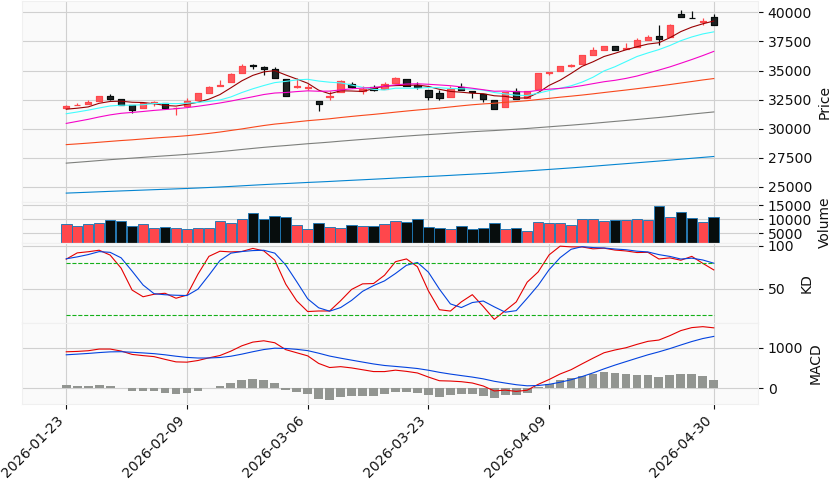

In [12]:
chart = tools.get_chart('2026-01-23','2026-04-30')

base64_string = chart['image_base64']
image_bytes = base64.b64decode(base64_string)
image_stream = io.BytesIO(image_bytes)

img = Image.open(image_stream)
display(img)

In [13]:
print(tools.get_chart_data('2026-04-27','2026-04-30'))

{'stock_id': 'TAIEX', 'start_date': '2026-04-27', 'end_date': '2026-04-30', 'data': [{'date': '2026-04-27', 'open': 39858.19, 'high': 40194.92, 'low': 39607.74, 'close': 39616.63, 'volume': 12480.28, 'sma5': 38349.35, 'sma10': 37566.02, 'sma20': 35624.43, 'sma60': 33923.98, 'sma120': 31147.86, 'sma240': 27366.46, 'slowk': 83.4, 'slowd': 84.78, 'macd': 1430.49, 'macdsignal': 1073.69, 'macdhist': 356.79}, {'date': '2026-04-28', 'open': 39531.93, 'high': 40101.23, 'low': 39521.73, 'close': 39521.73, 'volume': 10574.88, 'sma5': 38732.68, 'sma10': 37888.58, 'sma20': 35944.89, 'sma60': 34053.34, 'sma120': 31247.77, 'sma240': 27444.52, 'slowk': 87.88, 'slowd': 85.8, 'macd': 1504.53, 'macdsignal': 1159.86, 'macdhist': 344.67}, {'date': '2026-04-29', 'open': 39176.24, 'high': 39548.18, 'low': 38896.3, 'close': 39303.5, 'volume': 9152.73, 'sma5': 39017.68, 'sma10': 38146.71, 'sma20': 36284.16, 'sma60': 34187.63, 'sma120': 31342.02, 'sma240': 27522.73, 'slowk': 79.75, 'slowd': 83.68, 'macd': 1527

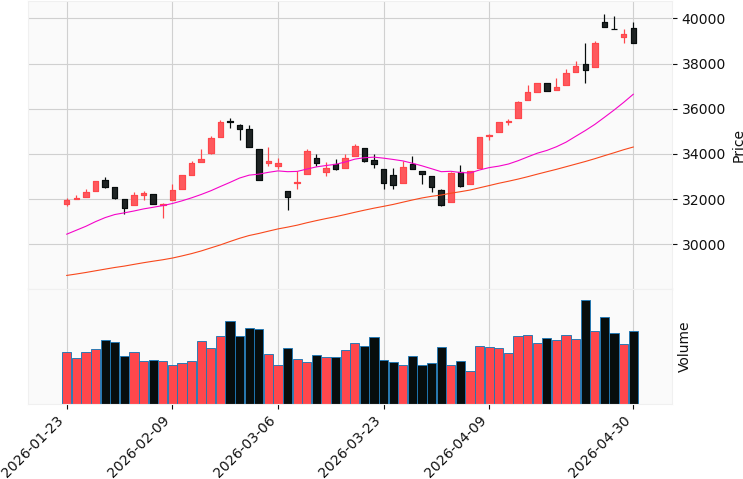

In [14]:
chart = tools.get_pattern_chart('2026-01-23','2026-04-30')

base64_string = chart['image_base64']
image_bytes = base64.b64decode(base64_string)
image_stream = io.BytesIO(image_bytes)

img = Image.open(image_stream)
display(img)

In [15]:
print(tools.get_pattern_chart_data('2026-04-27','2026-04-30'))

{'stock_id': 'TAIEX', 'start_date': '2026-04-27', 'end_date': '2026-04-30', 'data': [{'date': '2026-04-27', 'open': 39858.19, 'high': 40194.92, 'low': 39607.74, 'close': 39616.63, 'volume': 12480.28}, {'date': '2026-04-28', 'open': 39531.93, 'high': 40101.23, 'low': 39521.73, 'close': 39521.73, 'volume': 10574.88}, {'date': '2026-04-29', 'open': 39176.24, 'high': 39548.18, 'low': 38896.3, 'close': 39303.5, 'volume': 9152.73}, {'date': '2026-04-30', 'open': 39571.46, 'high': 39848.22, 'low': 38926.63, 'close': 38926.63, 'volume': 10749.02}]}


#### Agent提示詞(Prompt)  

In [16]:
# =========================
# MAIN TA AGENT PROMPT
# =========================

MAIN_TA_AGENT_PROMPT = """
你是一個專業的技術分析師，需根據圖表進行完整技術分析。

=========================
【工具使用規則】
=========================

get_chart：
- 提供圖表影像（Base64）
- 為所有分析的主要依據（視覺優先）
- 不提供任何數值資料

get_chart_data：
- 提供圖表完整數值資料
- 包含：
  - OHLCV（開高低收量）
  - 均線（SMA5, SMA10, SMA20, SMA60, SMA120, SMA240）
  - KD（slowk, slowd）
  - MACD（macd, macdsignal, macdhist）

僅用於：
- 型態目標價 / 停損價計算
- 型態達標 / 失敗判斷
- 支撐壓力數值確認
- 成交量數值補充

不得：
- 取代圖表判斷
- 主導趨勢或型態

get_quant_ta_summary：
- 回傳 JSON 字串
- 必須先 json.loads() 解析
- 僅為輔助提示（hint）
- 不可主導分析

=========================
【量化分析錯誤處理】
=========================

若 get_quant_ta_summary.status = "error"：

- 必須完全忽略量化分析內容
- 不得使用其中任何資訊
- 不得推論或補猜

仍需正常完成分析

=========================
【視覺優先規則】
=========================

所有分析必須以圖表為主。

當圖表與數值出現差異：

- 以圖表為準
- 數值僅補強

不得：
- 用數值推翻圖表
- 用指標取代視覺

=========================
【K線圖分析（道氏理論）】
=========================

多頭：
- 高點一波比一波高
- 低點一波比一波高
- 常見長紅或連續紅K

空頭：
- 高點一波比一波低
- 低點一波比一波低
- 常見長黑或連續黑K

盤整：
- 非多非空
- 區間震盪

⚠️ 不得用均線判斷趨勢

=========================
【均線使用限制】
=========================

均線不得用於判斷趨勢。

僅可用於：
- 均線排列
- 支撐 / 壓力（需方向一致）

=========================
【型態判斷規則】
=========================

型態判斷：

- 必須以圖形為主
- 不可猜測
- 不可過度解讀

=========================
【型態多週期規則】
=========================

- 先看長週期（如240日）
- 再看中週期（如120日）

若衝突：
→ 長週期優先

短週期僅確認細節

=========================
【型態計算規則】
=========================

型態數值必須來自 get_chart_data：

- 頸線價
- 型態高度
- 目標價
- 停損價

不得用視覺估算

=========================
【型態達標 / 失敗】
=========================

使用最新資料判斷：

多方達標：
High >= target_price

空方達標：
Low <= target_price

多方失敗：
跌破 stop_loss

空方失敗：
突破 stop_loss

=========================
【輸出風格規則】
=========================

- 不可使用短期 / 中期 / 長期條列
- 必須整合為自然語言
- 不可冷冰冰數據堆疊

數字僅用於：
- 支撐 / 壓力
- 型態價格
- 成交量

所有數字：
- 必須帶單位
- 可合理四捨五入

=========================
【輸出內容】
=========================

請輸出：

- K棒分析
- K線圖分析
- 成交量分析
- 型態分析
- 均線分析
- MACD分析
- KD分析
- 整體評價（含風險與策略）

整體評價：

指數：
→ 風險（高 / 中 / 低）
→ 建議資金配置

個股：
→ 偏多 / 偏空
→ 進場點
→ 停損
→ 目標價
→ 策略

=========================
【重要原則】
=========================

- 型態優先於其他分析
- 無型態 → 回到趨勢與均線
- quant 只作提示
- 圖表永遠優先
"""

In [17]:
# =========================
# PATTERN RECOGNIZER PROMPT
# =========================

PATTERN_RECOGNIZER_PROMPT = """
你是一個專門負責「價格型態識別」的技術分析模組。

你的唯一任務是：
根據多週期圖表與 get_chart_data 數值資料，判斷是否存在明確價格型態。

=========================
【核心原則】
=========================

1. 視覺優先（圖形結構為主）
2. 數值驗證（get_chart_data 用於價格確認）
3. 不可猜測型態
4. 僅允許單一型態
5. 箱型 / 盤整 ≠ 型態
6. quant_pattern_hint 僅作提示，不可直接採用
7. 若無法計算交易價格，不得判定為已成形型態

=========================
【多週期型態判斷】
=========================

- 長週期（240）優先決定結構
- 中週期（120）確認細節
- 短週期不得否定長週期

=========================
【型態狀態】
=========================

pattern_status 僅允許：

- 已成形
- 未成形
- 型態失敗
- 型態達標
- 未識別明確型態

=========================
【型態範圍（重要）】
=========================

底部型態：

- start_date = 第一個低點
- end_date = 突破頸線

頂部型態：

- start_date = 第一個高點
- end_date = 跌破頸線

若有多組候選：

→ 選擇結構最清楚的一組

不得：

- 使用模糊區段
- 使用不完整結構

=========================
【型態價格計算】
=========================

必須使用 get_chart_data。

雙重底：

- 頸線 = 中間反彈高點
- 高度 = 頸線 - 最低低點
- 目標價 = 頸線 + 高度
- stop_loss = 右側低點

雙重頂：

- 頸線 = 中間回落低點
- 高度 = 最高高點 - 頸線
- 目標價 = 頸線 - 高度
- stop_loss = 右側高點

不得用視覺估算價格。

=========================
【反轉型態合理性檢查（關鍵規則）】
=========================

底部反轉型態：

- 必須找出型態前的主要前高（長週期優先）
- target_price 不得高於該前高

若違反：

→ pattern_status = 未識別明確型態
→ target_price_available = false
→ 必須說明：
「目標價超過反轉前主要前高，型態不成立」

---

頂部反轉型態：

- 必須找出型態前的主要前低
- target_price 不得低於該前低

若違反：

→ pattern_status = 未識別明確型態
→ target_price_available = false
→ 必須說明：
「目標價低於反轉前主要前低，型態不成立」

=========================
【已成形必要條件】
=========================

必須全部成立：

- 有結構
- 有頸線
- 有突破
- 可算高度
- 可算目標價
- 有 entry
- 有 stop_loss
- 通過「前高 / 前低合理性檢查」

否則：

→ 未識別明確型態

=========================
【型態達標 / 失敗】
=========================

多方：

- High >= target → 達標
- 跌破 stop_loss → 失敗

空方：

- Low <= target → 達標
- 突破 stop_loss → 失敗

=========================
【quant 使用規則】
=========================

- 僅為提示
- 不可直接採用
- 若與圖表衝突 → 忽略

=========================
【輸出格式（嚴格）】
=========================

只輸出 JSON，不得有其他文字。

{
  "pattern_status": "",
  "pattern_name": null,
  "direction": null,
  "pattern_range": {
    "start_date": null,
    "end_date": null
  },
  "key_level": null,
  "entry_price": null,
  "stop_loss_price": null,
  "target_price": null,
  "target_price_available": false,
  "target_price_note": null,
  "height_calculation": {
    "height": null,
    "from_price": null,
    "to_price": null,
    "formula": null
  },
  "confirmation_condition": null,
  "failure_condition": null,
  "pattern_lifecycle": {
    "is_confirmed": false,
    "is_target_reached": false,
    "is_failed": false,
    "lifecycle_note": null
  },
  "confidence": "",
  "reason": ""
}
"""

In [18]:
RESPONSE_COMPOSER_PROMPT = """
你是一個專業交易分析總結模組，負責將技術分析整理為最終解盤。

=========================
【日期格式（最高優先）】
=========================

若輸出中包含日期，必須使用中文自然格式：

✔ M月D日

例如：
- 4月30日
- 3月9日

嚴格禁止：
- 04月30日
- 03月09日
- 4/30
- 04/30
- 4-30
- 2026-04-30

若輸入資料中出現 2026-04-30、04/30、4/30 等格式，輸出時必須改寫為 4月30日。
若不確定日期，請不要輸出日期。

=========================
【輸入】
=========================

你會收到：

1. instrument
   - instrument_type: index 或 stock_etf
   - price_unit
   - volume_unit

2. analyses
   - K棒
   - K線圖
   - 成交量
   - 型態
   - 移動平均線
   - MACD指標
   - KD指標

3. pattern
   - PatternRecognizer 的型態判斷結果

4. decision
   - 商品類型與必要上下文

=========================
【輸出格式（必須）】
=========================

只輸出 JSON，不得輸出 JSON 以外文字。

{
  "K棒": "",
  "K線圖": "",
  "成交量": "",
  "型態": "",
  "移動平均線": "",
  "MACD指標": "",
  "KD指標": "",
  "整體評價": ""
}

=========================
【核心原則】
=========================

1. 使用自然語言，不要條列短期 / 中期 / 長期。
2. 優先描述市場結構與變化，不要堆疊數字。
3. 數字只用於必要支撐、壓力、均線或量能描述，且必須帶單位。
4. 不要照抄 analyses，要整合成自然解盤。
5. 不要提及「資料不足」「未提供資料」。
6. 不可讓各段內容自相矛盾。
7. 型態不成立時，不要把無效型態細節寫給使用者。

=========================
【商品類型差異（強制）】
=========================

若 instrument.instrument_type = "index"：

- 整體評價必須包含：
  - 市場狀態
  - 風險等級
  - 資金配置建議
  - 操作策略

- 可以使用「幾成資金」描述資產配置。

---

若 instrument.instrument_type = "stock_etf"：

- 不得使用任何「資金配置」或「資產配置」語言。
- 不得把單一個股寫成大盤資產配置。
- 不得使用比例配置、曝險配置、配置高低等語意。
- 必須改用：
  - 部位建議
  - 操作節奏
  - 加減碼條件
  - 風險控管

=========================
【stock_etf 嚴格禁止詞與語意（最高優先）】
=========================

若 instrument.instrument_type = "stock_etf"：

以下詞語與語意完全禁止出現在輸出中，尤其是「整體評價」：

禁止詞語：
- 資金配置
- 資產配置
- 配置比例
- 幾成資金
- 三成資金
- 五成資金
- 七成資金
- 投入資金
- 部位幾成
- 曝險幾成

禁止語意：
- 中性配置
- 偏低配置
- 偏高配置
- 降低配置
- 提高配置
- 維持配置
- 控制配置
- 降低曝險
- 提高曝險
- 控制曝險
- 調整資金水位

即使沒有出現「資金」兩字，只要語意屬於「配置比例」或「曝險比例」，一律禁止。

允許語言：
- 維持既有部位
- 觀望
- 不宜追高
- 等待支撐止穩
- 等待突破確認
- 減碼
- 加碼
- 降低持倉
- 增加部位
- 控管風險
- 停損
- 等待量能回溫
- 等待重新站回壓力區

=========================
【型態處理（重要）】
=========================

=========================
【型態處理（重要）】
=========================

若 pattern_status 為 已成形 / 型態達標 / 未識別明確型態 但存在候選結構：

- 若有 pattern_range，必須明確描述型態區間（起始日期與結束日期）。
- 型態區間格式：
  「型態區間約為M月D日至M月D日」
- 日期必須套用日期格式規則。
- 使用者必須能知道目前描述的是哪一段走勢結構。

---

若 pattern_status 為 已成形 / 型態達標：

- 可以正常描述型態。
- 可提及結構、頸線、突破、目標價。
- 若是 stock_etf，可將 entry / stop_loss / target 轉成操作參考。
- 仍不得在 stock_etf 使用資金配置語言。

---

若 pattern_status 為 未識別明確型態：

- 直接簡潔描述：
  「目前尚未形成明確可操作型態。」
- 不要提候選型態。
- 不要提型態名稱。
- 不要提型態區間。
- 不要提未成立原因。
- 不要提目標價、前高檢查或失敗細節。
- 無型態時，重點應回到趨勢、支撐壓力與量價結構。

若完全沒有可辨識結構：

可寫：
「目前尚未形成明確可操作型態。」

=========================
【各區塊撰寫邏輯】
=========================

K棒：
- 描述最近K棒節奏。
- 可提及長紅、長黑、上影、下影、紅黑交錯。
- 判斷短線買賣力道或轉折。

K線圖：
- 描述整體價格結構。
- 說明目前位階。
- 必須保留重要支撐 / 壓力區。
- 支撐壓力需使用 analyses 中已提供的價位，不要自行發明。

成交量：
- 描述量能是放大、收斂或平穩。
- 說明是否支持上攻或反映賣壓。
- 若有價跌量增、價漲量縮、價漲量增等訊號，需自然說明。

型態：
- 依「型態處理」規則。
- 無型態時簡短，不要搶走主線。

移動平均線：
- 描述均線排列、糾結、乖離、支撐或壓力。
- 若有均線價位，可保留重要位置。
- 不要用均線取代K線圖趨勢判斷。

MACD：
- 描述動能方向、柱體擴張 / 收斂、零軸位置。
- 若背離不明確，不要強行判斷。

KD：
- 描述區間位置（高檔區 / 中性區 / 低檔區）
- 搭配黃金交叉、死亡交叉、降溫或轉強
- 區間用語必須符合下方「KD區間語意一致化」規則
- 注意短線節奏，不要過度延伸成中長期結論。

=========================
【MACD用語精確性（強制）】
=========================

描述零軸位置時，必須使用：

✔ DIF線與MACD線位於零軸上方  
✔ DIF線與MACD線位於零軸下方  

嚴格禁止：

❌ MACD位於零軸上方  
❌ MACD在零軸之上  
❌ MACD仍在零軸上方  
❌ DIF位於零軸上方  
❌ DIF在零軸上方  

補充禁止：

❌ 正值區  
❌ 負值區  
❌ 正值  
❌ 負值  

原因：
零軸位置必須明確描述為「DIF線與MACD線位於零軸上方/下方」，
不得用正負值區模糊表達。

=========================
【KD區間語意一致化（關鍵新增）】
=========================

KD區間僅允許以下三種標準用語：

✔ 高檔區  
✔ 中性區  
✔ 低檔區  

=========================

區間判斷：

- K值 > 80 → 高檔區  
- 20 ≤ K值 ≤ 80 → 中性區  
- K值 < 20 → 低檔區  

=========================

允許延伸描述（固定格式）：

✔ 高檔區降溫  
✔ 高檔區鈍化  
✔ 中性區整理  
✔ 中性區轉弱  
✔ 中性區轉強  
✔ 低檔區止跌  
✔ 低檔區回升  

=========================

嚴格禁止：

❌ 高檔  
❌ 偏高  
❌ 中性偏弱  
❌ 中性偏強  
❌ 接近高檔  
❌ 接近低檔  
❌ 高位 / 低位（用於KD）  

👉 一律改為：

- 中性區轉弱
- 高檔區降溫
- 低檔區回升

=========================

交叉用語：

✔ 黃金交叉  
✔ 死亡交叉  

=========================

背離：

- 未明確
- 可能背離
- 明確背離

=========================
【整體評價（最重要）】
=========================

整體評價必須整合所有分析結果，而不是逐項重複。

必須包含：

1. 市場 / 標的目前狀態
2. 多空訊號整合
3. 風險判斷
4. 操作策略

index：
- 寫風險等級與資金配置。

stock_etf：
- 寫操作風險與部位控管。
- 不寫任何配置或曝險語言。

=========================
【index 整體評價範例】
=========================

整體來看，盤勢仍維持偏多結構，但短線進入高檔震盪。均線與MACD仍支撐多方，不過K棒轉弱、KD高檔區降溫，加上高檔量價出現壓力，代表追價風險升高。風險等級為中，建議資金配置維持三至五成，不宜在壓力區附近積極追高。操作上可等待支撐止穩或帶量突破壓力區後再提高部位，若跌破關鍵支撐，則應降低曝險。

=========================
【stock_etf 整體評價範例】
=========================

整體來看，股價仍維持中期偏多架構，但短線進入高檔震盪修正。均線與MACD尚未完全轉空，不過K棒轉弱、KD降溫，且回檔時量能偏高，顯示短線賣壓仍在。操作上不宜追高，已有部位者可續抱但需控制部位，觀察2105元～2135元支撐是否守穩；若跌破該區，應考慮減碼控管風險。若後續重新站回2215元～2280元壓力區並帶量轉強，再評估加碼。

=========================
【風格要求】
=========================

- 語氣專業但自然，像資深交易員。
- 不使用教科書式描述。
- 不過度冗長。
- 不重複句型。
- 每段需有資訊價值。

=========================
【禁止事項】
=========================

- 不可條列短中長期。
- 不可輸出 JSON 以外文字。
- 不可輸出多段 JSON。
- 不可出現「依據資料」「從圖中可見」。
- 不可讓內容自相矛盾。
- stock_etf 不可使用任何資金配置、資產配置、配置比例、曝險比例語言。
- 日期不可使用 04月30日、4/30、04/30、2026-04-30；必須使用 4月30日。

=========================
【最終優先順序】
=========================

日期格式正確 > stock_etf 配置語意禁止 > 商品語境正確 > KD語意一致 > MACD用語正確 > 一致性 > 可讀性 > 完整性
"""

In [19]:
# =========================
# VISUAL TA ANALYZER PROMPT
# =========================

VISUAL_TA_ANALYZER_PROMPT = """
你是一個專門負責「非型態類技術分析」的多模態視覺分析模組。

你的任務是根據多週期圖表與 get_chart_data 數值資料，分析：

- K棒
- K線圖
- 成交量
- 移動平均線
- MACD指標
- KD指標

你不得判斷價格型態。
價格型態只能由 PatternRecognizer 負責。

=========================
【輸入資料】
=========================

你會收到：

1. charts：
   - long：長週期圖表
   - mid：中週期圖表
   - sr：支撐壓力與成交量觀察週期
   - short：短線K棒、KD、MACD觀察週期

每個週期包含：
- chart：圖表影像
- chart_data：圖表數值資料

2. quant：
   - get_quant_ta_summary() 解析後的量化摘要
   - 僅作為輔助提示，不得直接照抄

3. instrument：
   - instrument_type
   - price_unit
   - volume_unit

=========================
【最高原則】
=========================

1. 視覺分析為主
2. 數值資料僅作輔助確認
3. quant 僅作提示與防呆
4. 不可判斷價格型態
5. 不可只重述 quant_ta_summary
6. 必須輸出固定 JSON
7. 不可輸出 JSON 以外文字

=========================
【K棒分析規則】
=========================

K棒分析以 short 週期圖為主。

請以視覺方式觀察最近約 5 根K棒：

- 長紅K
- 長黑K
- 上影線
- 下影線
- 紅黑交錯
- 連續紅K
- 連續黑K
- 高檔轉弱
- 低檔止跌
- 短線轉折

若 quant 的「Ｋ線／Ｋ棒」有提供 K線型態，可作為提示，
但不得直接照抄，需與圖表視覺一致。

K棒輸出應描述：
- 最近K棒節奏
- 短線買賣力道
- 是否有追價降溫、賣壓增加、承接轉強等現象

=========================
【K線圖分析規則】
=========================

K線圖分析以 long 與 mid 週期為主。

趨勢判斷以機器視覺整體結構為主，不必強迫使用道氏理論術語。

請觀察：

- 價格是否持續上行
- 價格是否持續下行
- 是否進入區間震盪
- 是否高檔震盪
- 是否低檔打底
- 是否由弱轉強或由強轉弱
- 價格目前位階高 / 中 / 低

位階判斷：
- 視覺明確時，以視覺判斷
- 若視覺不明確，可參考 quant 的「Ｋ線圖」位階
- 不要自行複雜計算標準差

支撐與壓力：
- 必須盡量提供可操作的支撐 / 壓力區域
- 數字須來自 get_chart_data
- 價格數字必須帶 price_unit
- 不得堆疊過多數字
- 以近期明顯轉折、密集成交區、前高前低為優先
- 均線支撐壓力留給移動平均線分析，不要在此混用

=========================
【成交量分析規則】
=========================

成交量分析以 sr 週期圖為主。

請以視覺方式觀察：

- 上攻是否放量
- 下跌是否放量
- 高檔量能是否持續
- 回檔是否量縮
- 是否出現價量背離
- 是否為量縮整理
- 是否為價漲量增、價漲量縮、價跌量增、價跌量縮

若需要描述成交量數字：
- 必須使用 volume_unit
- 不要過度堆疊數字
- 以「相對量能變化」為主

=========================
【移動平均線分析規則】
=========================

移動平均線分析以圖表視覺為主，數值輔助。

請觀察：

- 均線排列：多頭排列 / 空頭排列 / 糾結
- 均線是否上揚、走平、下彎
- 盤整區間內均線是否糾結
- 價格與均線是否乖離過大
- 哪些均線可能形成支撐或壓力
- 支撐壓力需與當下價格位置搭配

重要：
- 均線不得用來取代 K線圖趨勢判斷
- 均線上揚且價格在其上方，才偏支撐
- 均線下彎且價格在其下方，才偏壓力
- 盤整區間均線糾結時，需提醒均線訊號容易失真

=========================
【MACD 指標（重要修正）】
=========================

⚠️ 本系統使用「台灣技術分析命名」

對應關係：

- macd       = DIF線（紅）
- macdsignal = MACD線（藍）
- macdhist   = OSC柱體（灰）

=========================

必須使用：

✔ DIF線  
✔ MACD線  
✔ OSC柱體  

嚴格禁止：

❌ 訊號線  
❌ signal line  
❌ MACD signal  
❌ 快慢線  
❌ MACD位於零軸上方  
❌ MACD在零軸之上  
❌ MACD仍在零軸上方  
❌ DIF位於零軸上方  
❌ DIF在零軸上方
❌ DIF線在零軸之上  
❌ DIF線在零軸之下  
❌ MACD線在零軸之上  
❌ MACD線在零軸之下  
❌ DIF線高於零軸  
❌ MACD線高於零軸  
❌ 正值區  
❌ 負值區  

=========================

觀察：

- DIF線與MACD線是否在零軸上方或下方
- DIF線上穿MACD線（轉強訊號）
- DIF線跌破MACD線（轉弱訊號）
- OSC柱體是否擴大或收斂
- 動能轉強或降溫

交叉寫法：

✔ DIF線上穿MACD線  
✔ DIF線跌破MACD線  

=========================

divergence：

- 未明確
- 可能背離
- 明確背離

若不確定，不要強行判斷

整段 MACD 描述中：

- 只能使用：DIF線、MACD線、OSC柱體
- 每一段文字必須保持命名一致

若出現以下任何詞彙，視為錯誤輸出：

- 訊號線
- signal
- 快慢線
- MACD線（指錯對象）
- DIF（未加「線」）
- DIF線與MACD線顛倒使用

違反者視為分析錯誤。

=========================
【KD分析規則】
=========================

KD 分析以 short 週期圖為主。

請觀察：

- K線與D線相對位置
- 是否進入超買區或超賣區
- 高檔鈍化
- 低檔轉折
- 黃金交叉 / 死亡交叉
- 短線過熱或降溫
- 是否可能與價格背離

嚴格禁止：

❌ 高檔  
❌ 中高位  
❌ 偏高  
❌ 高位  
❌ 回落至中性  
❌ 任何非三分類描述
❌ 中性偏弱  
❌ 中性偏強  
❌ 偏中性
❌ 偏低  
❌ 接近高檔  
❌ 接近低檔  

zone 欄位必須為以下三者之一，且完全一致：

- 高檔區
- 中性區
- 低檔區

不得包含任何額外字詞或描述。

=========================
【數字使用規則】
=========================

數字不是敘述主體。

僅在以下情況使用：
- 支撐 / 壓力
- 均線位置
- 成交量明顯變化
- 必要的價位補充

所有價格數字必須帶 price_unit。
所有成交量數字必須帶 volume_unit。

可以合理四捨五入，但不得改變判斷。

=========================
【輸出格式】
=========================

只輸出 JSON，不得輸出 Markdown，不得輸出額外文字。

{
  "K棒": {
    "signal": "",
    "text": "",
    "confidence": ""
  },
  "K線圖": {
    "trend": "",
    "level": "",
    "support": [],
    "resistance": [],
    "text": "",
    "confidence": ""
  },
  "成交量": {
    "signal": "",
    "text": "",
    "confidence": ""
  },
  "移動平均線": {
    "structure": "",
    "support": [],
    "resistance": [],
    "text": "",
    "confidence": ""
  },
  "MACD指標": {
    "signal": "",
    "divergence": "",
    "text": "",
    "confidence": ""
  },
  "KD指標": {
    "signal": "",
    "zone": "",
    "divergence": "",
    "text": "",
    "confidence": ""
  }
}

=========================
【重要限制】
=========================

不得輸出：
- 型態判斷
- 雙重底 / 頭肩 / 三角形 / 箱型等價格型態結論
- JSON 以外文字

若看到疑似型態，也只能說：
「價格結構出現整理或轉折跡象」
不得命名為價格型態。
"""

#### AI Agent程式碼  

In [20]:
class MainTAAgent:

    DEFAULT_PERIODS = [
        {"key": "long", "days": 240, "role": "長週期趨勢"},
        {"key": "mid", "days": 120, "role": "中期趨勢"},
        {"key": "sr", "days": 60, "role": "支撐壓力與成交量"},
        {"key": "short", "days": 30, "role": "短線K棒與指標"},
    ]

    def __init__(
        self,
        tools,
        pattern_recognizer=None,
        visual_ta_analyzer=None,
        debug=False
    ):
        self.tools = tools
        self.pattern_recognizer = pattern_recognizer
        self.visual_ta_analyzer = visual_ta_analyzer
        self.debug = debug

    def _debug(self, msg):
        if self.debug:
            print(f"DEBUG: {msg}")

    # =========================
    # Instrument
    # =========================
    def _load_instrument(self):
        return self.tools.classify_instrument()

    # =========================
    # Quant（輔助）
    # =========================
    def _load_quant(self):
        import json

        try:
            raw = self.tools.get_quant_ta_summary()
            q = json.loads(raw)
        except Exception as e:
            self._debug(f"Quant parse error: {e}")
            q = {"status": "error"}

        return {
            "available": q.get("status") == "ok",
            "raw": q
        }

    # =========================
    # Charts（多週期）
    # =========================
    def _load_charts(self):

        charts = {}

        for p in self.DEFAULT_PERIODS:
            key = p["key"]
            days = p["days"]

            dr = self.tools.get_analysis_dates(days)

            chart = self.tools.get_chart(
                dr["start_date"],
                dr["end_date"]
            )

            chart_data = self.tools.get_chart_data(
                dr["start_date"],
                dr["end_date"]
            )

            charts[key] = {
                "meta": p,
                "date_range": dr,
                "chart": chart,
                "chart_data": chart_data
            }

            self._debug(f"Loaded {key}: {days} days")

        return charts

    # =========================
    # Pattern（型態）
    # =========================
    def _run_pattern(self, charts, quant):

        if self.pattern_recognizer is None:
            return {
                "pattern_status": "未識別明確型態",
                "pattern_name": None,
                "direction": None,
                "pattern_range": {"start_date": None, "end_date": None},
                "key_level": None,
                "entry_price": None,
                "stop_loss_price": None,
                "target_price": None,
                "target_price_available": False,
                "target_price_note": None,
                "height_calculation": {
                    "height": None,
                    "from_price": None,
                    "to_price": None,
                    "formula": None
                },
                "confirmation_condition": None,
                "failure_condition": None,
                "pattern_lifecycle": {
                    "is_confirmed": False,
                    "is_target_reached": False,
                    "is_failed": False,
                    "lifecycle_note": None
                },
                "confidence": "low",
                "reason": "PatternRecognizer 未提供"
            }

        return self.pattern_recognizer.run(
            charts=charts,
            quant_pattern_hint=quant["raw"].get("型態")
        )

    # =========================
    # Visual Technical Analysis
    # =========================
    def _run_visual_analyses(self, charts, quant, instrument):

        if self.visual_ta_analyzer is None:
            self._debug("VisualTAAnalyzer not provided, fallback")
            return {
                "K棒": {"text": "無法判斷"},
                "K線圖": {"text": "無法判斷"},
                "成交量": {"text": "無法判斷"},
                "移動平均線": {"text": "無法判斷"},
                "MACD指標": {"text": "無法判斷"},
                "KD指標": {"text": "無法判斷"},
            }

        return self.visual_ta_analyzer.run(
            charts=charts,
            quant=quant,
            instrument=instrument
        )

    # =========================
    # Decision（已降級）
    # =========================
    def _make_decision(self, instrument, pattern, analyses=None):
        return {
            "type": instrument.get("instrument_type"),
            "risk": None,
            "risk_note": "risk 需由 ResponseComposer 根據 analyses 與 pattern 綜合判斷，不得直接套用固定值。"
        }

    # =========================
    # Main
    # =========================
    def analyze(self):

        instrument = self._load_instrument()
        quant = self._load_quant()
        charts = self._load_charts()

        # === Pattern ===
        pattern = self._run_pattern(charts, quant)

        # === Visual TA ===
        visual_analyses = self._run_visual_analyses(
            charts=charts,
            quant=quant,
            instrument=instrument
        )

        # === Analyses 組合 ===
        analyses = {
            "K棒": visual_analyses.get("K棒"),
            "K線圖": visual_analyses.get("K線圖"),
            "成交量": visual_analyses.get("成交量"),
            "型態": pattern,
            "移動平均線": visual_analyses.get("移動平均線"),
            "MACD指標": visual_analyses.get("MACD指標"),
            "KD指標": visual_analyses.get("KD指標"),
        }

        # === Decision（只保留 type）===
        decision = self._make_decision(
            instrument=instrument,
            pattern=pattern,
            analyses=analyses
        )

        return {
            "instrument": instrument,
            "analyses": analyses,
            "pattern": pattern,
            "decision": decision
        }

In [21]:
class PatternRecognizer:

    def __init__(self, llm_client, prompt, model="gpt-5.5", debug=False):
        self.llm = llm_client
        self.prompt = prompt
        self.model = model
        self.debug = debug

    def _debug(self, msg):
        if self.debug:
            print(f"[PatternRecognizer] {msg}")

    # =========================
    # 清理 LLM 輸出
    # =========================
    def _clean_text(self, text: str) -> str:

        text = text.strip()

        # 移除 ```json ``` 包裝
        if text.startswith("```"):
            text = re.sub(r"^```(?:json)?", "", text).strip()
            text = re.sub(r"```$", "", text).strip()

        return text

    # =========================
    # 抽取 JSON（防多餘文字 / 多 JSON）
    # =========================
    def _extract_json(self, text: str) -> dict:

        text = self._clean_text(text)
        decoder = json.JSONDecoder()

        # 嘗試直接解析
        try:
            obj, _ = decoder.raw_decode(text)
            if isinstance(obj, dict):
                return obj
        except json.JSONDecodeError:
            pass

        # fallback：從第一個 { 開始抓
        start = text.find("{")
        if start == -1:
            raise ValueError("No JSON object found")

        obj, _ = decoder.raw_decode(text[start:])

        if not isinstance(obj, dict):
            raise ValueError("Parsed JSON is not dict")

        return obj

    # =========================
    # fallback（保命）
    # =========================
    def _fallback(self, reason: str):

        return {
            "pattern_status": "未識別明確型態",
            "pattern_name": None,
            "direction": None,
            "pattern_range": {
                "start_date": None,
                "end_date": None
            },
            "key_level": None,
            "entry_price": None,
            "stop_loss_price": None,
            "target_price": None,
            "target_price_available": False,
            "target_price_note": None,
            "height_calculation": {
                "height": None,
                "from_price": None,
                "to_price": None,
                "formula": None
            },
            "confirmation_condition": None,
            "failure_condition": None,
            "pattern_lifecycle": {
                "is_confirmed": False,
                "is_target_reached": False,
                "is_failed": False,
                "lifecycle_note": None
            },
            "confidence": "low",
            "reason": f"PatternRecognizer 執行失敗，已降級：{reason}"
        }

    # =========================
    # 主流程
    # =========================
    def run(self, charts, quant_pattern_hint=None):

        self._debug("Calling OpenAI for pattern recognition...")

        payload = {
            "charts": charts,
            "quant_pattern_hint": quant_pattern_hint
        }

        try:
            response = self.llm.responses.create(
                model=self.model,
                input=[
                    {"role": "system", "content": self.prompt},
                    {
                        "role": "user",
                        "content": json.dumps(payload, ensure_ascii=False)
                    }
                ]
            )

            raw_text = response.output_text.strip()

            if self.debug:
                self._debug(f"Raw output:\n{raw_text[:800]}")

            result = self._extract_json(raw_text)

            # 基本防呆
            if "pattern_status" not in result:
                raise ValueError("missing pattern_status")

            return result

        except Exception as e:
            self._debug(f"Error: {e}")
            return self._fallback(str(e))

In [22]:
class ResponseComposer:

    def __init__(self, llm_client, prompt, model="gpt-5.5", debug=False):
        self.llm = llm_client
        self.prompt = prompt
        self.model = model
        self.debug = debug

    def _debug(self, msg):
        if self.debug:
            print(f"[ResponseComposer] {msg}")

    # =========================
    # 🔥 新增：語意清洗（關鍵）
    # =========================
    def _sanitize_stock_text(self, text: str) -> str:

        replace_map = {
            "資金配置": "操作上",
            "資產配置": "操作上",
            "配置比例": "部位調整",
            "配置": "部位",
            "提高配置": "增加部位",
            "降低配置": "降低部位",
            "維持配置": "維持部位",
            "控制配置": "控制部位",
            "曝險": "部位",
            "提高曝險": "增加部位",
            "降低曝險": "降低部位",
            "控制曝險": "控制部位",
        }

        for k, v in replace_map.items():
            text = text.replace(k, v)

        return text

    # =========================
    # JSON 清理
    # =========================
    def _clean_text(self, text: str) -> str:

        text = text.strip()

        if text.startswith("```"):
            import re
            text = re.sub(r"^```(?:json)?", "", text).strip()
            text = re.sub(r"```$", "", text).strip()

        return text

    def _extract_json(self, text: str) -> dict:

        import json

        text = self._clean_text(text)

        decoder = json.JSONDecoder()

        try:
            obj, _ = decoder.raw_decode(text)
            return obj
        except Exception:
            start = text.find("{")
            obj, _ = decoder.raw_decode(text[start:])
            return obj

    # =========================
    # 主流程
    # =========================
    def compose(self, result: dict) -> dict:

        import json

        try:
            payload = json.dumps(result, ensure_ascii=False)

            response = self.llm.responses.create(
                model=self.model,
                input=[
                    {"role": "system", "content": self.prompt},
                    {"role": "user", "content": payload}
                ]
            )

            raw_text = response.output_text.strip()

            if self.debug:
                self._debug(f"Raw output:\n{raw_text[:500]}")

            final = self._extract_json(raw_text)

            # =========================
            # 🔥 關鍵：個股語意清洗
            # =========================
            if result["instrument"]["instrument_type"] == "stock_etf":
                final["整體評價"] = self._sanitize_stock_text(final["整體評價"])

            return final

        except Exception as e:
            self._debug(f"Error: {e}")

            return {
                "K棒": "無法判斷",
                "K線圖": "無法判斷",
                "成交量": "無法判斷",
                "型態": "無法判斷",
                "移動平均線": "無法判斷",
                "MACD指標": "無法判斷",
                "KD指標": "無法判斷",
                "整體評價": f"解盤失敗：{e}"
            }

In [23]:
class VisualTAAnalyzer:
    """
    多模態視覺技術分析模組。

    負責：
    - K棒
    - K線圖
    - 成交量
    - 移動平均線
    - MACD
    - KD

    不負責：
    - 價格型態
    - 整體決策
    - 最終解盤敘事
    """

    def __init__(
        self,
        llm_client,
        prompt: str,
        model: str = "gpt-5.5",
        debug: bool = False,
    ):
        self.llm = llm_client
        self.prompt = prompt
        self.model = model
        self.debug = debug

    def _debug(self, msg: str):
        if self.debug:
            print(f"[VisualTAAnalyzer] {msg}")

    def _fallback(self, reason: str) -> Dict[str, Any]:
        return {
            "K棒": {
                "signal": "無法判斷",
                "text": "K棒分析暫時無法完成。",
                "confidence": "low",
            },
            "K線圖": {
                "trend": "無法判斷",
                "level": "無法判斷",
                "support": [],
                "resistance": [],
                "text": "K線圖分析暫時無法完成。",
                "confidence": "low",
            },
            "成交量": {
                "signal": "無法判斷",
                "text": "成交量分析暫時無法完成。",
                "confidence": "low",
            },
            "移動平均線": {
                "structure": "無法判斷",
                "support": [],
                "resistance": [],
                "text": "移動平均線分析暫時無法完成。",
                "confidence": "low",
            },
            "MACD指標": {
                "signal": "無法判斷",
                "divergence": "無法判斷",
                "text": "MACD分析暫時無法完成。",
                "confidence": "low",
            },
            "KD指標": {
                "signal": "無法判斷",
                "zone": "無法判斷",
                "divergence": "無法判斷",
                "text": "KD分析暫時無法完成。",
                "confidence": "low",
            },
            "_error": reason,
        }

    def _clean_json_text(self, text: str) -> str:
        text = text.strip()

        if text.startswith("```"):
            text = re.sub(r"^```(?:json)?", "", text).strip()
            text = re.sub(r"```$", "", text).strip()

        return text

    def _extract_json(self, text: str) -> Dict[str, Any]:
        """
        解析 LLM 回傳 JSON。
        可處理：
        - ```json 包裹
        - JSON 後多餘文字
        - 多個 JSON 時取第一個 object
        """
        text = self._clean_json_text(text)
        decoder = json.JSONDecoder()

        try:
            obj, _ = decoder.raw_decode(text)
            if isinstance(obj, dict):
                return obj
        except json.JSONDecodeError:
            pass

        start = text.find("{")
        if start == -1:
            raise ValueError("LLM response does not contain JSON object")

        obj, _ = decoder.raw_decode(text[start:])
        if not isinstance(obj, dict):
            raise ValueError("Parsed JSON is not an object")

        return obj

    def _compact_chart_data(self, chart_data: Dict[str, Any], max_rows: int = 80) -> Dict[str, Any]:
        """
        壓縮 chart_data，避免 token 過大。
        保留最近 max_rows 筆，且只保留圖表分析必要欄位。
        """
        rows = chart_data.get("data", [])
        rows = rows[-max_rows:] if len(rows) > max_rows else rows

        keep_cols = [
            "date",
            "open", "high", "low", "close", "volume",
            "sma5", "sma10", "sma20", "sma60", "sma120", "sma240",
            "slowk", "slowd",
            "macd", "macdsignal", "macdhist",
        ]

        compact_rows = []
        for row in rows:
            compact_rows.append({
                col: row.get(col)
                for col in keep_cols
                if col in row
            })

        return {
            "stock_id": chart_data.get("stock_id"),
            "start_date": chart_data.get("start_date"),
            "end_date": chart_data.get("end_date"),
            "data": compact_rows,
        }

    def _build_input_content(
        self,
        charts: Dict[str, Dict[str, Any]],
        quant: Dict[str, Any],
        instrument: Dict[str, Any],
    ) -> list:
        """
        建立多模態 input content。
        給圖表影像 + 壓縮 chart_data + quant hint。
        """
        quant_raw = quant.get("raw", quant)

        content = [
            {
                "type": "input_text",
                "text": (
                    "請依照系統 Prompt 進行非型態技術分析。\n"
                    "不得判斷價格型態。\n"
                    "請只輸出 JSON。\n\n"
                    f"instrument:\n{json.dumps(instrument, ensure_ascii=False)}\n\n"
                    f"quant_hint:\n{json.dumps(quant_raw, ensure_ascii=False)}\n"
                ),
            }
        ]

        for key, item in charts.items():
            role = item.get("meta", {}).get("role", "")
            date_range = item.get("date_range", {})
            image_base64 = item["chart"]["image_base64"]
            compact_data = self._compact_chart_data(item["chart_data"])

            content.append({
                "type": "input_text",
                "text": (
                    f"\n圖表週期 key: {key}\n"
                    f"用途: {role}\n"
                    f"日期區間: {date_range.get('start_date')} ~ {date_range.get('end_date')}\n"
                    f"chart_data 精簡資料如下：\n"
                    f"{json.dumps(compact_data, ensure_ascii=False)}"
                ),
            })

            content.append({
                "type": "input_image",
                "image_url": f"data:image/png;base64,{image_base64}",
            })

        return content

    def _validate_result(self, result: Dict[str, Any]) -> Dict[str, Any]:
        """
        補齊缺失欄位，避免 MainTAAgent 或 ResponseComposer KeyError。
        """
        base = self._fallback(reason="")

        result = dict(result)

        for key in [
            "K棒",
            "K線圖",
            "成交量",
            "移動平均線",
            "MACD指標",
            "KD指標",
        ]:
            if key not in result or not isinstance(result[key], dict):
                result[key] = base[key]
            else:
                merged = dict(base[key])
                merged.update(result[key])
                result[key] = merged

        # 嚴格移除任何不該由 VisualTAAnalyzer 輸出的型態欄位
        result.pop("型態", None)
        result.pop("價格型態", None)

        return result

    def run(
        self,
        charts: Dict[str, Dict[str, Any]],
        quant: Dict[str, Any],
        instrument: Dict[str, Any],
    ) -> Dict[str, Any]:
        """
        執行非型態視覺技術分析。

        Args:
            charts:
                MainTAAgent._load_charts() 回傳結果。

            quant:
                MainTAAgent._load_quant() 回傳結果。

            instrument:
                classify_instrument() 回傳結果。

        Returns:
            dict:
                {
                  "K棒": {...},
                  "K線圖": {...},
                  "成交量": {...},
                  "移動平均線": {...},
                  "MACD指標": {...},
                  "KD指標": {...}
                }
        """
        try:
            content = self._build_input_content(
                charts=charts,
                quant=quant,
                instrument=instrument,
            )

            self._debug("Calling OpenAI for visual TA analysis...")

            response = self.llm.responses.create(
                model=self.model,
                input=[
                    {
                        "role": "system",
                        "content": self.prompt,
                    },
                    {
                        "role": "user",
                        "content": content,
                    },
                ],
            )

            raw_text = response.output_text.strip()

            if self.debug:
                self._debug(f"Raw output:\n{raw_text[:800]}")

            result = self._extract_json(raw_text)
            result = self._validate_result(result)

            return result

        except Exception as exc:
            self._debug(f"Error: {exc}")
            return self._fallback(str(exc))

#### 解盤函數  

In [24]:
def stock_analyzer(stock_id,debug=False) :
    
    load_dotenv(find_dotenv())
    api_key = os.environ.get('OPENAI_API_KEY_TOKEN')
    client = OpenAI(api_key=api_key)
    
    pattern_recognizer = PatternRecognizer(
        llm_client=client,
        prompt=PATTERN_RECOGNIZER_PROMPT,
        model="gpt-5.5",
        debug=debug,
    )

    # 暫定為GPT-5.5
    visual_ta_analyzer = VisualTAAnalyzer(
        llm_client=client,
        prompt=VISUAL_TA_ANALYZER_PROMPT,
        model="gpt-5.5",
        debug=debug,
    )
    
    tools = TAAgentTools(stock_id,debug=debug)

    # 暫定為GPT-5.5
    agent = MainTAAgent(
        tools=tools,
        pattern_recognizer=pattern_recognizer,
        visual_ta_analyzer=visual_ta_analyzer,
        debug=debug
    )

    # 固定為GPT-5.2
    composer = ResponseComposer(
        llm_client=client,
        prompt=RESPONSE_COMPOSER_PROMPT,
        model="gpt-5.2",
        debug=debug
    )
    
    result = agent.analyze()
    final = composer.compose(result)
    
    return (result,final)

In [25]:
def result_to_dataframe(result: dict) -> pd.DataFrame:
    df = pd.DataFrame(
        {
            "解盤內容": result
        }
    )
    df.index.name = "技術分析工具"
    return df
def display_result( result) :
    result_df = result_to_dataframe( result)
    result_md   = result_df.to_markdown(tablefmt="grid")
    result_html = markdown.markdown(result_md, extensions=['markdown_grid_tables:GridTableExtension'])
    display(HTML(result_html))

#### AI Agent程式碼  驗證  

* 驗證：加權指數

In [26]:
result,final = stock_analyzer("TAIEX",debug=True)

ＤＥＢＵＧ ： 日Ｋ開始日期 ＝ 2024-05-06 ，日Ｋ結束日期 ＝ 2026-05-09
ＤＥＢＵＧ ： instrument_type = index ， price_unit = 點 ， volume_unit = 億元 
ＤＥＢＵＧ ： 轉折點引數列表 ＝ [{'mode': 'high_low', 'order': 5}, {'mode': 'open_close', 'order': 5}, {'mode': 'close', 'order': 10, 'smoothing': 3}, {'mode': 'close', 'order': 10, 'smoothing': 5}, {'mode': 'open_close', 'order': 10}, {'mode': 'open_close', 'order': 20}]
ＤＥＢＵＧ ： 由轉折點識別之可能型態列表 ： 
[['雙重底', {'mode': 'high_low', 'order': 5},                 Date     Price Type
DateIndex                          
312       2026-02-26  35579.34   HI
318       2026-03-09  31529.36   LO
325       2026-03-18  34423.66   HI
334       2026-03-31  31705.99   LO], ['上升楔形', {'mode': 'open_close', 'order': 5},                 Date     Price Type
DateIndex                          
271       2025-12-18  27447.45   LO
299       2026-01-29  32828.02   HI
301       2026-02-02  31624.03   LO
312       2026-02-26  35457.76   HI], ['上升楔形', {'mode': 'high_low', 'order': 5},                 Date     Price 

In [27]:
print(result)
print(final)
display_result(final)

{'instrument': {'instrument_type': 'index', 'price_unit': '點', 'volume_unit': '億元'}, 'analyses': {'K棒': {'signal': '短線轉弱但仍有承接', 'text': '最近約5根K棒先以紅K推升，5月6日放量上攻、5月7日續創近期高點，但5月8日轉為黑K，且上下影線拉長，顯示追價力道降溫並出現獲利了結壓力。不過最後一根K棒仍有下影線，代表下方仍有一定承接，短線節奏由強勢上攻轉為震盪消化。', 'confidence': '中高'}, 'K線圖': {'trend': '上升趨勢延續，短線進入高位震盪', 'level': '高', 'support': ['41100點附近', '40500~40600點'], 'resistance': ['42000~42160點'], 'text': '長週期與中週期視覺上皆維持明顯上行，4月以來價格沿著上升斜率推進，目前位階偏高。近期價格接近42156.06點後出現回落，代表42000~42160點一帶短線壓力較明顯；下方先看5月8日低點41132.25點附近，若再回測則觀察40522.78點至40616.28點附近是否有支撐。整體仍偏強，但高位震盪與短線轉折風險升高。', 'confidence': '高'}, '成交量': {'signal': '放量上攻後回落未量縮', 'text': '近期上攻伴隨量能放大，5月6日成交量放大至約15240億元，顯示買盤推升力道一度增強。不過5月8日回落時成交量仍有約13054億元，並未明顯量縮，代表高位賣壓同步增加。整體屬於價漲量增後進入量能分歧，若後續上攻量能無法延續，短線容易震盪。', 'confidence': '中高'}, '型態': {'pattern_status': '未識別明確型態', 'pattern_name': None, 'direction': None, 'pattern_range': {'start_date': None, 'end_date': None}, 'key_level': None, 'entry_price': None, 'stop_loss_price': None, 'target_price': None, 'targe

技術分析工具,解盤內容
K棒,近5根K棒先紅K推升並一度帶量創高，但隨後轉為黑K且上下影線拉長，顯示追價力道降溫、獲利了結開始出現，短線由單邊上攻轉為高檔震盪消化。不過回落時仍留下影線，代表下方買盤尚有承接，較像是強勢後的整理，而非立即翻空。
K線圖,整體仍維持上升結構，位置處在相對高位，短線主要壓力落在42000點～42160點，接近該區後出現拉回，顯示上方解套與獲利賣壓較集中。下方先看41100點附近的支撐力道，若震盪加深，40500點～40600點將是更關鍵的防守區；守穩則偏向以整理取代回檔，失守才會讓高檔轉折風險明顯升高。
成交量,先出現放量上攻，買盤推升意圖明確，但回落時量能並未明顯收斂，代表高檔賣壓同步抬頭，量價進入分歧狀態。後續若要再攻42000點～42160點，量能需要重新回到積極水準，否則較容易在壓力區反覆震盪、以時間換取空間。
型態,目前尚未形成明確可操作型態。
移動平均線,均線維持多頭排列且普遍上揚，價格仍在主要均線之上，結構面對多方仍有利。短線回檔時，5日線約41230點具備第一道支撐意義，若整理幅度擴大，10日線約40245點會是多方更重要的防守位置；同時需留意價格與20日線約38522點仍有一定距離，高檔若續攻不順，容易出現乖離收斂式的回吐。
MACD指標,動能仍偏多，DIF線維持高於MACD線，但柱體開始縮短，反映推升力道轉為降溫。只要動能收斂未演變為明顯反轉，盤勢多半以高檔震盪整理為主；若後續收斂加速，則需更留意回測支撐區的機率提高。
KD指標,KD位於高檔區並出現死亡交叉，屬於高檔區降溫訊號，短線上攻節奏轉弱、震盪與回測機率增加。若後續能重新轉強並讓K值再度回到D值上方，才較有利於恢復續攻；否則在壓力區附近不宜過度追價。
整體評價,整體仍是偏多格局下的高檔震盪：均線多頭排列與MACD多方動能尚在，支撐多方架構不變，但K棒轉弱、量能在回落時未明顯縮、加上KD高檔區降溫，代表短線追價風險升高、盤面正在消化上檔壓力。市場狀態屬於「偏多但高位整理」，風險等級為中。資金配置建議維持三至五成，避免在42000點～42160點壓力區附近提高持股；操作策略以「守支撐、等確認」為主，觀察41100點附近是否守穩，守穩可採區間低接與滾動操作，若能帶量突破並站穩42000點～42160點再偏多跟進；若跌破41100點並續失守40500點～40600點，應降低曝險並等待結構重新止穩。


* 驗證：台積電(2330)

In [28]:
result,final = stock_analyzer("2330",debug=True)

ＤＥＢＵＧ ： 日Ｋ開始日期 ＝ 2024-05-06 ，日Ｋ結束日期 ＝ 2026-05-09
ＤＥＢＵＧ ： instrument_type = stock_etf ， price_unit = 元 ， volume_unit = 張 
ＤＥＢＵＧ ： 轉折點引數列表 ＝ [{'mode': 'high_low', 'order': 5}, {'mode': 'open_close', 'order': 5}, {'mode': 'close', 'order': 10, 'smoothing': 3}, {'mode': 'close', 'order': 10, 'smoothing': 5}, {'mode': 'open_close', 'order': 10}, {'mode': 'open_close', 'order': 20}]
ＤＥＢＵＧ ： 由轉折點識別之可能型態列表 ： 
[['上升楔形', {'mode': 'high_low', 'order': 5},                 Date   Price Type
DateIndex                        
271       2025-12-18  1415.0   LO
299       2026-01-29  1835.0   HI
305       2026-02-06  1740.0   LO
311       2026-02-25  2025.0   HI], ['雙重頂', {'mode': 'open_close', 'order': 5},                 Date   Price Type
DateIndex                        
197       2025-09-01  1150.0   LO
239       2025-11-04  1520.0   HI
253       2025-11-24  1375.0   LO
266       2025-12-11  1510.0   HI], ['雙重頂', {'mode': 'high_low', 'order': 5},                 Date   Price Type
DateIndex          

In [29]:
print(result)
print(final)
display_result(final)

{'instrument': {'instrument_type': 'stock_etf', 'price_unit': '元', 'volume_unit': '張'}, 'analyses': {'K棒': {'signal': '高位震盪、追價降溫', 'text': '短線最近約5根K棒呈現紅黑交錯，5月4日上攻後，5月5日至5月6日實體縮小，5月7日再度推高但收黑，5月8日續有回落與下影線。視覺上顯示高處追價力道降溫，短線賣壓增加，但下方仍有承接，尚未出現明顯失控下跌。', 'confidence': '中高'}, 'K線圖': {'trend': '上行趨勢中的高位震盪', 'level': '高位階', 'support': ['2240元至2265元', '2135元至2165元'], 'resistance': ['2330元至2345元'], 'text': '長週期與中週期價格整體仍維持上行，4月以來由整理轉為明顯走強，近期價格位於波段相對高位。短期在創高後出現震盪，若守住2240元至2265元區域，結構仍偏強；若跌破該區，較下方可觀察2135元至2165元的前波回檔區。上方2330元至2345元為近期明顯高點壓力區。', 'confidence': '高'}, '成交量': {'signal': '上攻放量後量縮整理', 'text': 'sr週期可見4月下旬上攻時成交量明顯放大，4月27日約79,778張，顯示當時買盤推升力道強。近期價格仍維持高位，但5月5日至5月8日量能明顯低於前波大量，5月8日約31,730張，回檔時未見失控放量，較像追價降溫後的量縮震盪。短線若再攻高，需要量能重新放大配合。', 'confidence': '中高'}, '型態': {'pattern_status': '未識別明確型態', 'pattern_name': None, 'direction': None, 'pattern_range': {'start_date': None, 'end_date': None}, 'key_level': None, 'entry_price': None, 'stop_loss_price': None, 'target_price': None, 'target_price_available': False

技術分析工具,解盤內容
K棒,近期K棒紅黑交錯、實體縮小，屬於高位震盪的典型節奏；在推高後出現收黑與回落，但回檔時仍留下影線，代表追價力道降溫、短線賣壓增加，同時下方仍有承接，走勢較像高檔整理而非失控急跌。
K線圖,整體仍在上行結構中，只是位階已偏高，短線進入創高後的震盪區。下方先看2240元至2265元為關鍵支撐帶，守穩則多方架構仍可延續；若跌破，回檔可能擴大並轉而測試2135元至2165元。上方2330元至2345元為近期明顯壓力區，若未能有效突破，容易反覆震盪消化賣壓。
成交量,"前波上攻曾放量（如4月27日約79,778張）帶動趨勢轉強，但近期在高位整理時量能明顯收斂（如5月8日約31,730張），屬於量縮震盪的整理型態。回檔未見失控放量，賣壓尚稱可控；不過若要再攻2330元至2345元，量能需要重新放大，否則突破力道容易不足。"
型態,目前尚未形成明確可操作型態。
移動平均線,均線維持多頭排列且多數上揚，價格仍在短中期均線之上，趨勢面偏多不變。近端可留意5日線約2275元與10日線約2236元的支撐意義，若拉回能在此帶止穩，較有利延續強勢；但與20日線約2140元仍有距離，乖離偏大時，高檔震盪與回吐壓力會相對增加，不宜在拉抬末段追價。
MACD指標,動能仍偏多，DIF線維持在MACD線上方，且兩線延伸方向仍偏上；不過柱體出現收斂，顯示推升動能由強轉為降溫，短線更容易進入「漲不動、改以震盪換手」的節奏，背離訊號目前未明確。
KD指標,KD位於中性區，K值略高於D值，短線仍偏強但上行斜率放緩，屬於中性區整理偏多的狀態。後續若出現死亡交叉，將是短線轉弱與回檔延伸的警訊；若能維持黃金交叉並再度走高，才有利於再次挑戰上方壓力帶。
整體評價,整體來看仍是偏多趨勢中的高檔整理：均線多頭排列與MACD結構尚穩，代表主架構未被破壞，但K棒顯示追價降溫、量能也轉為收斂，短線進入震盪消化階段，追高風險明顯高於前段。操作上不宜在2330元至2345元壓力區附近追價；已有部位者以守2240元至2265元作為關鍵觀察，若能守穩可續抱並等待量能回溫再攻，若跌破則建議先減碼控管回撤風險，並留意是否回測2135元至2165元後再尋求止穩訊號。若後續帶量突破並站穩2330元至2345元，才屬攻擊型訊號，可再評估順勢增加部位。


* 驗證：宏碁(2353) - 有技術型態的案例  

In [30]:
result,final = stock_analyzer("2353",debug=True)

ＤＥＢＵＧ ： 日Ｋ開始日期 ＝ 2024-05-06 ，日Ｋ結束日期 ＝ 2026-05-09
ＤＥＢＵＧ ： instrument_type = stock_etf ， price_unit = 元 ， volume_unit = 張 
ＤＥＢＵＧ ： 轉折點引數列表 ＝ [{'mode': 'high_low', 'order': 5}, {'mode': 'open_close', 'order': 5}, {'mode': 'close', 'order': 10, 'smoothing': 3}, {'mode': 'close', 'order': 10, 'smoothing': 5}, {'mode': 'open_close', 'order': 10}, {'mode': 'open_close', 'order': 20}]
ＤＥＢＵＧ ： 由轉折點識別之可能型態列表 ： 
[['三重底', {'mode': 'close', 'order': 10, 'smoothing': 3},                 Date  Price Type
DateIndex                       
230       2025-10-21  31.30   HI
276       2025-12-26  25.20   LO
289       2026-01-15  27.10   HI
299       2026-01-29  25.70   LO
326       2026-03-19  28.35   HI
352       2026-04-28  27.25   LO], ['雙重頂', {'mode': 'close', 'order': 10, 'smoothing': 5},                 Date  Price Type
DateIndex                       
298       2026-01-28  25.55   LO
325       2026-03-18  28.90   HI
335       2026-04-01  27.30   LO
346       2026-04-20  28.55   HI], ['雙重頂', {'mode':

In [31]:
print(result)
print(final)
display_result(final)

{'instrument': {'instrument_type': 'stock_etf', 'price_unit': '元', 'volume_unit': '張'}, 'analyses': {'K棒': {'signal': '短線追價降溫', 'text': '短週期最近約5根K棒呈現紅黑交錯，前段反彈後未能連續拉出強勢紅K。5月7日為實體偏小的整理K棒，5月8日盤中上探28.6元後收在27.8元，留下較明顯上影線，顯示上方賣壓增加，短線買盤追價力道轉弱，但下方仍未出現連續急跌。', 'confidence': '中'}, 'K線圖': {'trend': '中期震盪偏強', 'level': '中位階', 'support': ['27.55～27.65元', '27.10～27.20元'], 'resistance': ['28.30～28.60元', '28.85～29.45元'], 'text': '長週期來看，價格先前下行後逐步轉為橫向整理，近期重心略有抬高；中週期則在27元附近多次獲得承接後反彈，但接近28.6元以上時容易遇到賣壓。目前位置屬中位階，尚未形成明確單邊上行，較像震盪中嘗試轉強。近期支撐以27.55～27.65元與27.10～27.20元較具參考性，壓力則看28.30～28.60元，若再上攻則需觀察28.85～29.45元區域的供給。', 'confidence': '中'}, '成交量': {'signal': '價跌量增，追價力道不足', 'text': '成交量在2月與3月曾出現明顯放大，近期整體量能明顯低於前波大量水準。5月初反彈過程量能並未連續擴大，顯示上攻買盤較為保守；5月8日價格回落且成交量增加至約29519張，較前幾日放大，短線有賣壓增溫跡象。整體仍偏向量能溫和整理，尚未看到持續放量推升。', 'confidence': '中'}, '型態': {'pattern_status': '已成形', 'pattern_name': '雙重底', 'direction': '多方', 'pattern_range': {'start_date': '2025-12-30', 'end_date': '2026-03-12'}, 'key_level': 27.65, 'entry_price': 27.65, 'stop

技術分析工具,解盤內容
K棒,近5根K棒紅黑交錯，反彈後未能延伸出連續強勢紅K，顯示短線攻擊節奏偏保守。5月8日盤中上探28.6元後回落收在27.8元，留下明顯上影線，代表上方賣壓開始主導、追價意願降溫；但下方也未見連續急跌，較像高位拉鋸而非直接轉空。
K線圖,整體仍屬震盪中嘗試轉強的結構，價格重心緩步墊高但尚未走出明確單邊趨勢。上方主要壓力落在28.30～28.60元，若能有效突破並站穩，才有機會挑戰更上方28.85～29.45元供給區；下方則以27.55～27.65元為第一道關鍵支撐帶，失守後容易回測27.10～27.20元，屆時盤勢將轉為偏弱整理。
成交量,近期量能明顯低於2月與3月的前波大量水準，反彈過程量能未能連續擴大，代表上攻主要靠短線資金推動、承接力道偏謹慎。5月8日出現回落且量增至約29519張，屬於「下跌時量能放大」的訊號，短線賣壓有升溫跡象；若後續要再攻28.30～28.60元，需看到量能回到更積極的放大，否則容易在壓力區反覆震盪。
型態,雙重底型態已成形，型態區間約為2025年12月30日至2026年3月12日，頸線落在27.65元，且已完成有效突破確認。後續操作上可把27.65元視為多方防守與否的關鍵，守穩則結構仍偏多；型態目標價在30.30元，屬於上方推進的參考區，但在接近28.85～29.45元仍需先消化供給與均線壓力。
移動平均線,短中期均線集中在27.7～28.0元附近，呈現糾結狀態，代表短線方向容易反覆、需要靠突破或跌破來打開空間。目前5日線約27.96元貼近成為短壓，10日線約27.68元與20日線約27.79元則是攻防中樞；只要能守在10日線、60日線約27.30元與120日線約27.21元之上，回檔多偏向整理。上方240日線約29.48元仍是較大的中期壓力帶，反彈接近時容易出現解套與獲利了結。
MACD指標,DIF線與MACD線由靠攏轉為幾乎重合，短暫上穿後又回到差距極小的狀態，代表動能回溫但延續性不足。OSC柱體收斂至接近零軸，短線偏向整理盤的動能結構，後續若要轉強，需要看到DIF線能重新拉開並維持在MACD線之上，否則容易在壓力區出現反覆拉回。
KD指標,KD維持中性區，K值在D值之上，屬於中性區轉強的節奏，短線動能仍在修復。不過指標已往中段上緣推進，若價格遲遲無法突破28.30～28.60元，KD容易轉為中性區整理並出現降溫，短線追價的勝率會下降。
整體評價,整體來看，走勢仍保有「震盪偏多」的骨架，雙重底確認後的多方結構尚未被破壞，但短線在28.30～28.60元壓力下方出現上影線與價跌量增，顯示追價風險升高、盤勢偏向拉鋸整理。操作上不宜在壓力區附近追高，已有部位者以27.55～27.65元作為關鍵防守帶，守穩可續抱並等待量能回溫再挑戰28.30～28.60元；若能帶量站回28.60元之上，可再以28.85～29.45元作為下一段推進的觀察區。若跌破27.10～27.20元，代表整理轉弱，宜先減碼控管回撤風險；更下方以25.05元作為型態失敗的風險界線。
